# Chain capture and duration accuracy: EpiHiper ground truth vs. the genomic tree

**Revision note.** The first pass of this notebook categorized chains by their *full* lifetime duration
and found the categorization nearly useless: with 96.8% of all infections sitting in the top 12 chains,
and those chains running the length of the whole simulation, a 4-26 week threshold on full duration barely
changed which chains qualified. It also surfaced the real reason two of the largest chains showed zero
capture -- they burned out before the sequencing window's coverage began -- which pointed at the fix: stop
counting infections that happened outside the period genomic surveillance could actually see, and measure
chain persistence *within that window* instead.

This revision restricts every infection to the sequencing window before computing anything. Two questions:

1. Categorized by how long a chain persisted *within the window* (still 4 to 26 weeks), what does that
   categorization actually look like once it isn't swamped by out-of-window chain lifetime?
2. Within a chain, how far off is the genomic tree's own estimate of the time separating two infections
   from what actually happened -- and does that error track the duration category from (1)?

The premise behind dropping the capture-fraction framing was that surveillance likely sequenced "all or
most" in-window infections, making that metric uninteresting. Section 3 checks that directly rather than
assuming it, because it doesn't hold.


In [1]:
import sys, os, time
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from IPython.display import display

sys.path.insert(0, '.')
import chain_capture_data as cc

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 40)

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150, 'font.size': 10,
    'axes.grid': True, 'grid.alpha': 0.25, 'axes.spines.top': False,
    'axes.spines.right': False, 'figure.facecolor': 'white',
})

os.makedirs(cc.RESULTS_DIR, exist_ok=True)

COL = {'captured': '#12866E', 'total': '#4C6EF5', 'zero': '#C2255C',
       'bias': '#F08C00', 'mae': '#4C6EF5', 'rmse': '#C2255C', 'window': '#EDF2FF'}
print('ready')


ready


## 1. Load the two ground truths and match them up

`epi_graph.gpickle` is the full EpiHiper transmission forest. `nextstrain_tree_graph_300day.gpickle` is
the augur/TreeTime phylogeny for the `run_03_vadelta_2026_03_22_128to428_SURS` PhyloGAS run, whose tips
are named `USA/VA-EHip-{pid}.{tick:03d}/{year}` -- the same `pid`/`tick` identity used in the epi forest.


In [2]:
t0 = time.time()
epi_G = cc.load_epi_graph()
print(f"[{time.time()-t0:.0f}s] epi_G: {epi_G.number_of_nodes():,} infections, "
      f"{epi_G.number_of_edges():,} transmission edges")

t0 = time.time()
epi_tick, epi_parent = cc.build_epi_indices(epi_G)
epi_pid_tick_index = cc.build_epi_pid_tick_index(epi_G)
print(f'[{time.time()-t0:.0f}s] built tick/parent indices')


[57s] epi_G: 15,408,357 infections, 15,404,582 transmission edges


[86s] built tick/parent indices


In [3]:
gen_G = cc.load_gen_graph()
SEQ_WINDOW = cc.compute_sequencing_window(gen_G)
gen_to_epi = cc.match_gen_tips_to_epi_nodes(gen_G, epi_pid_tick_index)
epi_to_gen = {v: k for k, v in gen_to_epi.items()}
captured_epi_nodes = set(gen_to_epi.values())

gen_parent = {}
for u, v in gen_G.edges():
    gen_parent[v] = u
gen_num_date = {n: d.get('num_date') for n, d in gen_G.nodes(data=True)}

print(f'genomic tree: {gen_G.number_of_nodes():,} nodes, '
      f'{sum(1 for n in gen_G.nodes if gen_G.out_degree(n)==0):,} tips')
print(f'sequenced simulated tips matched to an epi infection: '
      f'{len(gen_to_epi):,} / {sum("EHip" in str(n) for n in gen_G.nodes if gen_G.out_degree(n)==0):,}')
print(f'sequencing window (simulation days): {SEQ_WINDOW[0]}-{SEQ_WINDOW[1]} '
      f'({SEQ_WINDOW[1]-SEQ_WINDOW[0]} days / {(SEQ_WINDOW[1]-SEQ_WINDOW[0])/7:.1f} weeks)')


genomic tree: 28,980 nodes, 14,793 tips
sequenced simulated tips matched to an epi infection: 14,791 / 14,791
sequencing window (simulation days): 169-425 (256 days / 36.6 weeks)


In [4]:
t0 = time.time()
component_df, node_to_component = cc.build_component_stats(
    epi_G, epi_tick, captured_epi_nodes, window=SEQ_WINDOW
)
print(f'[{time.time()-t0:.0f}s] {len(component_df):,} transmission chains '
      '(full-lifetime and in-window stats computed together)')

del epi_G  # everything needed downstream is in epi_tick / epi_parent / node_to_component

component_df.to_csv(f'{cc.RESULTS_DIR}/component_stats.csv', index=False)
print(f"chains with >=2 infections: {(component_df['size']>=2).sum():,} of {len(component_df):,} total")
print(f"chains with any infection inside the sequencing window: {(component_df['windowed_size']>0).sum():,}")


[58s] 7,550 transmission chains (full-lifetime and in-window stats computed together)
chains with >=2 infections: 2,066 of 7,550 total
chains with any infection inside the sequencing window: 5,314


## 2. Why windowing matters: the chain landscape

Chain sizes span seven orders of magnitude, and the two largest chains alone hold 72% of all infections.
The `run_03` genomic sample only covers simulation days 169-425, so a chain's *full* lifetime duration says
almost nothing about how much of it genomic surveillance could actually have seen.


In [5]:
top = component_df.sort_values('size', ascending=False).head(12).copy()
top['pct_of_all_infections'] = 100 * top['size'] / component_df['size'].sum()
display_cols = ['component_id', 'size', 'min_tick', 'max_tick', 'duration_days',
                'windowed_size', 'windowed_duration_days', 'n_captured', 'pct_of_all_infections']
print(f"Top 12 chains hold {top['pct_of_all_infections'].sum():.1f}% of all {component_df['size'].sum():,} infections")
top[display_cols].round(2)


Top 12 chains hold 96.8% of all 15,408,357 infections


,component_id,size,min_tick,max_tick,duration_days,windowed_size,windowed_duration_days,n_captured,pct_of_all_infections
164,164,7257994,137.0,699.0,562,3546617,256,10271,47.10
2,2,3866722,54.0,365.0,311,578704,196,0,25.09
240,240,1133572,150.0,699.0,549,568337,255,1565,7.36
187,187,805083,140.0,699.0,559,387566,256,1161,5.22
3,3,551321,61.0,323.0,262,72981,154,0,3.58
432,432,412813,193.0,699.0,506,207598,232,437,2.68
429,429,299969,193.0,699.0,506,137136,232,348,1.95
136,136,253019,133.0,699.0,566,124300,256,270,1.64
474,474,106740,211.0,699.0,488,42265,214,83,0.69
276,276,93172,155.0,699.0,544,49219,256,94,0.60


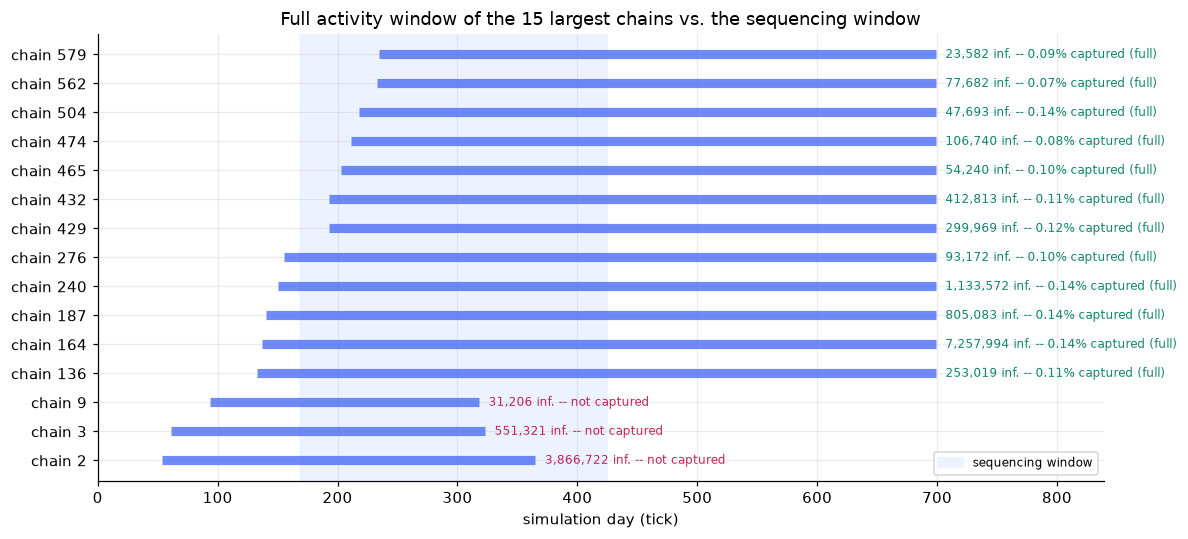

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
top_n = 15
plot_df = component_df.sort_values('size', ascending=False).head(top_n).sort_values('min_tick')

ax.axvspan(SEQ_WINDOW[0], SEQ_WINDOW[1], color=COL['window'], zorder=0, label='sequencing window')
for i, row in enumerate(plot_df.itertuples()):
    ax.hlines(i, row.min_tick, row.max_tick, color=COL['total'], lw=6, alpha=.8)
    label = f'{row.frac_captured:.2%} captured (full)' if row.n_captured else 'not captured'
    color = COL['captured'] if row.n_captured else COL['zero']
    ax.text(row.max_tick + 8, i, f'{row.size:,} inf. -- {label}', va='center', fontsize=8, color=color)

ax.set_yticks(range(top_n))
ax.set_yticklabels([f'chain {int(c)}' for c in plot_df['component_id']])
ax.set_xlabel('simulation day (tick)')
ax.set_title(f'Full activity window of the {top_n} largest chains vs. the sequencing window')
ax.set_xlim(0, plot_df['max_tick'].max() + 140)
ax.legend(loc='lower right', fontsize=8)
fig.tight_layout()
fig.savefig(f'{cc.RESULTS_DIR}/chain_activity_windows.png', bbox_inches='tight')
plt.show()


Two of the five largest chains (3.87M and 551k infections) show zero captured infections simply
because they burned out (day 365, day 323) before the window's coverage really overlaps -- not a sampling
failure, a timing one. Everything below restricts to infections inside the shaded band only.


## 2b. Epidemiological context: incidence, realized R, and serial interval

Before digging further into capture and dating bias, some basic epidemiological grounding for the same
period: the shape of the epidemic curve, how transmissible cases were, and how quickly they passed the
infection on. All three are computed globally (every chain pooled together, not just the ones examined
above) over the sequencing window *plus 3 months on each side* (`cc.MONTH_DAYS` = 30), so the run-up and
the tail-off around the window are visible too, not just the window itself.

- **Incidence**: infections per day.
- **Realized R**: for cases infected on day *t*, the mean number of secondary infections they went on to
  cause (their out-degree in the transmission forest) -- "realized" because it's counted from what actually
  happened in the simulation, not estimated from a renewal-equation model. Computed from the *entire*
  simulation, not just the reporting window, so a day near the window's edge isn't penalized for secondary
  infections that simply hadn't happened yet by the time the window closes.
- **Serial interval**: for that same day-*t* cohort, the mean number of days from their own infection to
  each secondary infection they caused. Paired with realized R by the same cohort definition.


In [7]:
t0 = time.time()
daily_df = cc.build_daily_epi_stats(epi_tick, epi_parent, seq_window=SEQ_WINDOW,
                                     months_before=3, months_after=3)
daily_df.to_csv(f'{cc.RESULTS_DIR}/daily_epi_stats.csv', index=False)
print(f"[{time.time()-t0:.0f}s] {len(daily_df)} days, tick {daily_df.tick.min()}-{daily_df.tick.max()} "
      f"(sequencing window {SEQ_WINDOW[0]}-{SEQ_WINDOW[1]} +/- 3 months)")
daily_df[['n_infected', 'realized_r', 'serial_interval_days']].describe().round(3)


[27s] 437 days, tick 79-515 (sequencing window 169-425 +/- 3 months)


,n_infected,realized_r,serial_interval_days
count,437.000,437.000,437.000
mean,26610.815,1.093,6.878
std,18514.808,0.450,0.168
min,693.000,0.585,6.370
25%,14943.000,0.933,6.859
50%,20157.000,1.002,6.944
75%,34214.000,1.059,6.978
max,81110.000,4.055,7.108


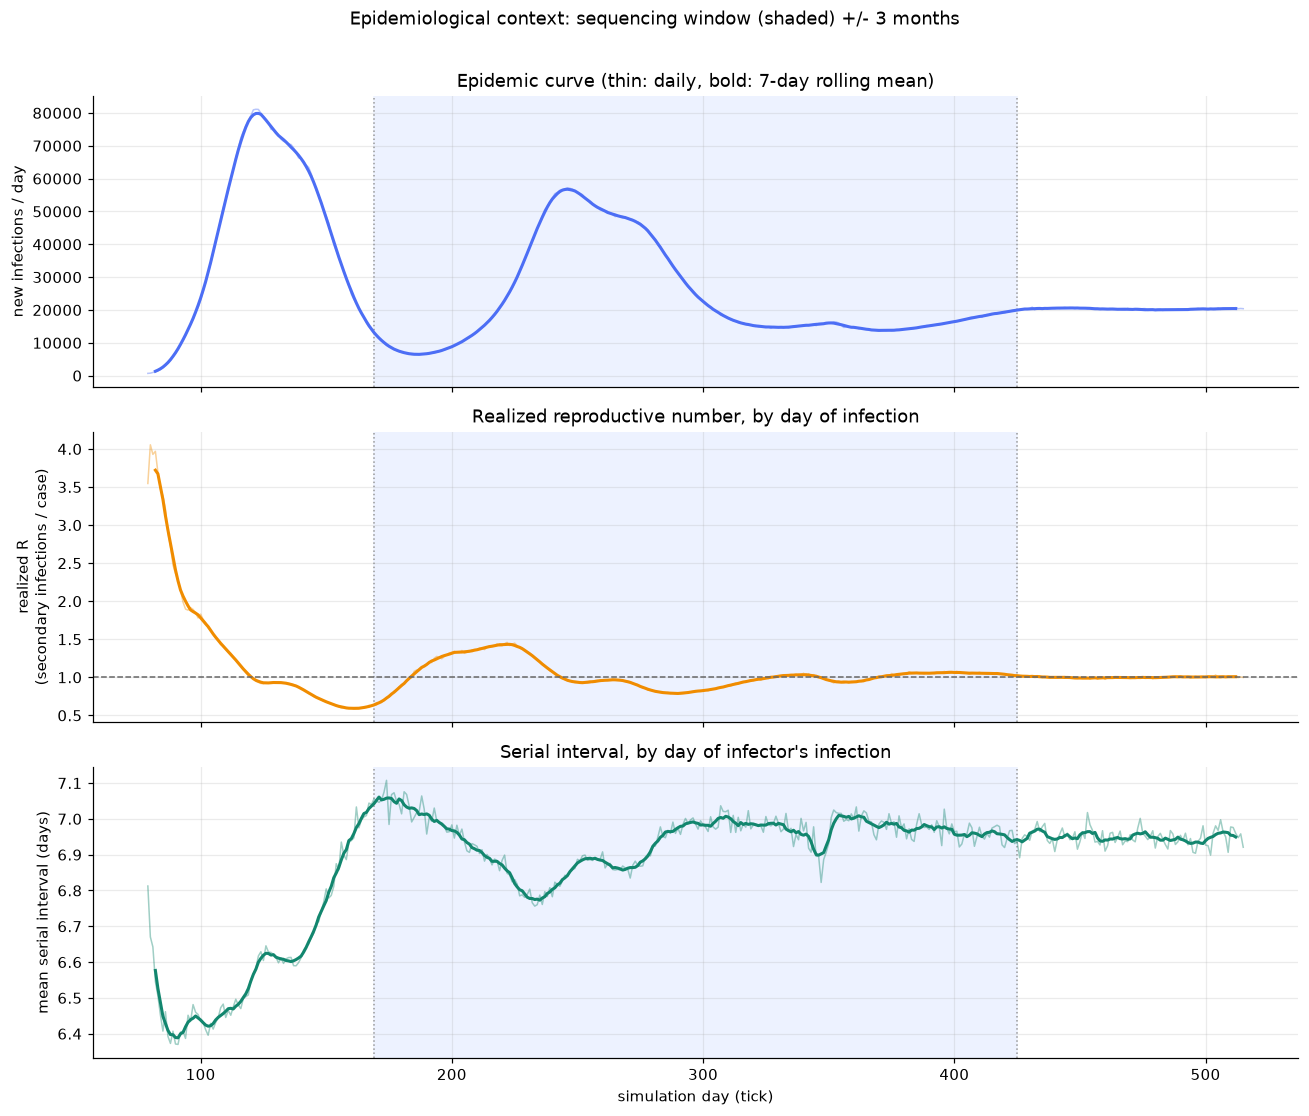

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

for ax in axes:
    ax.axvspan(SEQ_WINDOW[0], SEQ_WINDOW[1], color=COL['window'], zorder=0)
    ax.axvline(SEQ_WINDOW[0], color='0.6', ls=':', lw=1)
    ax.axvline(SEQ_WINDOW[1], color='0.6', ls=':', lw=1)

ax = axes[0]
ax.plot(daily_df.tick, daily_df.n_infected, color=COL['total'], lw=1, alpha=.4)
ax.plot(daily_df.tick, daily_df.n_infected.rolling(7, center=True).mean(), color=COL['total'], lw=2)
ax.set_ylabel('new infections / day')
ax.set_title('Epidemic curve (thin: daily, bold: 7-day rolling mean)')

ax = axes[1]
ax.plot(daily_df.tick, daily_df.realized_r, color=COL['bias'], lw=1, alpha=.4)
ax.plot(daily_df.tick, daily_df.realized_r.rolling(7, center=True).mean(), color=COL['bias'], lw=2)
ax.axhline(1, color='0.4', ls='--', lw=1)
ax.set_ylabel('realized R\n(secondary infections / case)')
ax.set_title('Realized reproductive number, by day of infection')

ax = axes[2]
ax.plot(daily_df.tick, daily_df.serial_interval_days, color=COL['captured'], lw=1, alpha=.4)
ax.plot(daily_df.tick, daily_df.serial_interval_days.rolling(7, center=True).mean(), color=COL['captured'], lw=2)
ax.set_ylabel('mean serial interval (days)')
ax.set_xlabel('simulation day (tick)')
ax.set_title("Serial interval, by day of infector's infection")

fig.suptitle('Epidemiological context: sequencing window (shaded) +/- 3 months', y=1.01)
fig.tight_layout()
fig.savefig(f'{cc.RESULTS_DIR}/daily_epi_context.png', bbox_inches='tight')
plt.show()


**The sequencing window sits on a second wave, not the epidemic's main event.** The epidemic curve shows
two clear waves: a much larger first wave peaking at ~79,900 infections/day around tick 123 -- entirely
*before* the window opens at 169 -- followed by a trough of ~8,950/day right as the window starts, then a
second, smaller wave peaking at ~56,800/day around tick 246 (inside the window), which decays to a stable
plateau of ~20,300/day for the rest of the observed period. **This directly explains Section 2's two
zero-capture giant chains**: chain 2 (tick 54-365, 3.87M infections) and chain 3 (tick 61-323, 551k
infections) both start right as the first wave ramps up and mostly conclude before or during the trough --
the bulk of their case-load happened during the wave the sequencing effort never covered, not because they
were sampled poorly but because they were largely finished by the time sampling started.

**Realized R crosses 1 twice around the window, consistent with the two-wave shape.** It starts high (3.56
at tick ~80, the early exponential-growth phase), falls through the first wave, bottoms at 0.59 right before
the window opens (tick 161, the trough), then climbs back to a local peak of 1.43 at tick 223, which is
what drives the second, in-window wave. It settles to R=1.00 for the long plateau after the window closes
(mean R for tick above 450), i.e. the late period is a stable endemic-like plateau, not growth or decline.

**Serial interval is tight (6.4-7.1 days, std 0.17 overall) but not perfectly constant, and it moves inversely
with R.** It's shortest (6.39 days) during the early high-R growth phase around tick 91, rises to its peak
(7.06 days) right as the window opens and R is at its trough, then dips again (6.77 days) around tick 235
during the second wave's R peak, before settling near 6.95 days in the low-transmission tail. This
inverse R-vs-serial-interval wobble is almost certainly what keeps Section 5b's generation-count-vs-duration
correlation just short of perfect (r=0.987, not 1.0) -- if the serial interval were exactly fixed, generation
count and elapsed calendar time would be exactly interchangeable.


## 3. Checking the premise: was in-window capture actually near-complete?

If genomic surveillance sequenced "all or most" infections during its own window, the capture-fraction
framing really would be uninteresting -- there'd be nothing left to explain. Checking directly, using only
infections whose tick falls in the window:


In [9]:
in_window = component_df[component_df['windowed_size'] > 0]
pooled_windowed_frac = component_df['n_captured'].sum() / component_df['windowed_size'].sum()

print(f"Infections inside the sequencing window: {component_df['windowed_size'].sum():,}")
print(f"Of those, sequenced: {component_df['n_captured'].sum():,}")
print(f"Pooled in-window capture fraction: {pooled_windowed_frac:.4%}\n")

multi_in_window = in_window[in_window['windowed_size'] >= 2]
print(f"{len(in_window):,} chains have any in-window infection; "
      f"{len(multi_in_window):,} have >=2 (i.e. onward transmission observed inside the window).")
print("windowed_frac_captured across those chains (not sequencing-weighted, one row per chain):")
multi_in_window['windowed_frac_captured'].describe().round(4)


Infections inside the sequencing window: 5,974,307
Of those, sequenced: 14,791
Pooled in-window capture fraction: 0.2476%

5,314 chains have any in-window infection; 1,901 have >=2 (i.e. onward transmission observed inside the window).
windowed_frac_captured across those chains (not sequencing-weighted, one row per chain):


count    1901.0000
mean        0.0015
std         0.0185
min         0.0000
25%         0.0000
50%         0.0000
75%         0.0000
max         0.5000
Name: windowed_frac_captured, dtype: float64

**The premise doesn't hold: in-window capture is ~0.25%, not "all or most."** Pooled across every
chain, only 1 in ~400 infections that happened during the sequencing window was ever sequenced. Restricting
to chains with onward in-window transmission, the median chain still has a 0% capture rate -- three
quarters of them do. This isn't a null result to wave off; it's the same sparse-surveillance picture as the
full-lifetime version, just no longer confounded by chains that were never in a position to be sampled at
all. The categorization in Section 4 is still worth doing, but it should be read as "does persistence
inside the window predict getting captured," not "how much of an already-near-total effort got captured."


## 4. Categorizing chains by how long they persisted *within* the window

Same method as before -- keep chains whose duration meets or exceeds each threshold from 4 to 26 weeks --
but duration is now the chain's span *inside* the 256-day (36.6-week) sequencing window, which comfortably
contains the requested range instead of being swamped by it.


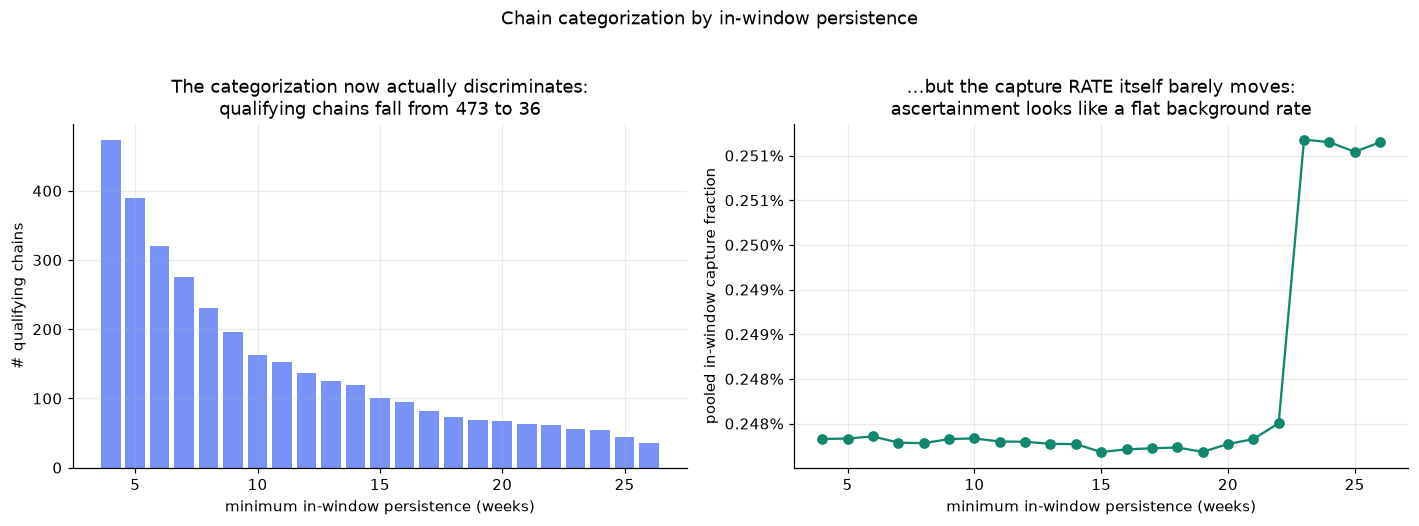

,threshold_weeks,threshold_days,n_chains,total_infections,total_captured,pooled_frac_captured,mean_chain_frac_captured,median_chain_frac_captured
0,4,28,473,5965441,14784,0.00248,0.00241,0.00000
1,5,35,389,5964112,14781,0.00248,0.00272,0.00000
2,6,42,320,5962730,14779,0.00248,0.00301,0.00000
3,7,49,275,5961585,14772,0.00248,0.00237,0.00000
4,8,56,230,5960122,14768,0.00248,0.00254,0.00000
5,9,63,196,5958209,14766,0.00248,0.00280,0.00026
6,10,70,163,5956002,14761,0.00248,0.00305,0.00131
7,11,77,153,5955239,14757,0.00248,0.00284,0.00166
8,12,84,137,5954077,14754,0.00248,0.00299,0.00196
9,13,91,125,5952240,14748,0.00248,0.00291,0.00208


In [10]:
capture_w = cc.capture_by_duration_threshold(
    component_df, duration_col='windowed_duration_days', size_col='windowed_size',
    captured_col='n_captured', frac_col='windowed_frac_captured'
)
capture_w.to_csv(f'{cc.RESULTS_DIR}/capture_by_threshold_windowed.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

ax = axes[0]
ax.bar(capture_w.threshold_weeks, capture_w.n_chains, color=COL['total'], alpha=.75)
ax.set_xlabel('minimum in-window persistence (weeks)')
ax.set_ylabel('# qualifying chains')
ax.set_title('The categorization now actually discriminates:\nqualifying chains fall from 473 to 36')

ax = axes[1]
ax.plot(capture_w.threshold_weeks, capture_w.pooled_frac_captured, 'o-', color=COL['captured'])
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:.3%}'))
ax.set_xlabel('minimum in-window persistence (weeks)')
ax.set_ylabel('pooled in-window capture fraction')
ax.set_title('...but the capture RATE itself barely moves:\nascertainment looks like a flat background rate')

fig.suptitle('Chain categorization by in-window persistence', y=1.03)
fig.tight_layout()
fig.savefig(f'{cc.RESULTS_DIR}/capture_by_threshold_windowed.png', bbox_inches='tight')
plt.show()
capture_w.round(5)


Restricting to the window fixes the categorization itself -- the number of qualifying chains now
drops by 92% (473 -> 36) across the 4-26 week range instead of barely moving. But the pooled capture
*rate* among qualifying chains stays close to 0.248% regardless of the threshold. Put together with
Section 3: ascertainment here behaves like a roughly constant per-infection sampling rate, not something
that improves for chains that persist longer inside the window.


## 5. Duration between infections: does the genomic tree's bias track chain persistence?

This is the main question. For each pair of sequenced infections sharing a chain, compare:

- **actual duration** = (tick_a - tick_mrca) + (tick_b - tick_mrca), using the true transmission-tree MRCA
  and its exactly-known tick.
- **genomic duration** = the same construction on the phylogeny, using the internal `NODE_*` MRCA and its
  TreeTime-inferred `num_date` -- the piece that carries real estimation error (tip dates are fixed input,
  not inferred, so a tip-to-tip comparison would be circular).

Pairs are grouped by their chain's **in-window persistence**, categorized the same way as Section 4.


In [11]:
t0 = time.time()
pairs = cc.sample_pairs_per_component(component_df, node_to_component, captured_epi_nodes,
                                       max_pairs_per_component=500, seed=42)
pair_error_df = cc.compute_pair_duration_errors(
    pairs, epi_tick, epi_parent, epi_to_gen, gen_num_date, gen_parent, component_df
)
pair_error_df.to_csv(f'{cc.RESULTS_DIR}/pair_duration_errors.csv', index=False)
print(f"[{time.time()-t0:.1f}s] {len(pair_error_df):,} pairs across "
      f"{pair_error_df['component_id'].nunique()} chains with >=2 sequenced infections")
print()
print('In-window persistence of the chains these pairs come from:')
pair_error_df['windowed_duration_days'].describe().round(1)


[0.3s] 7,714 pairs across 59 chains with >=2 sequenced infections

In-window persistence of the chains these pairs come from:


count    7714.0
mean      222.9
std        27.8
min        42.0
25%       192.0
50%       222.0
75%       256.0
max       256.0
Name: windowed_duration_days, dtype: float64

Chains that ever produce a *pair* of sequenced infections are heavily concentrated near the top of
the persistence range (median in-window duration 222 of a possible 256 days) -- unsurprising, since it
takes a large, long-running chain to accumulate two sequenced cases by chance. That skew is exactly why
Section 4's categorization needs to extend past 26 weeks to see all of it: a 4-26 week cut alone would
silently drop 95% of these pairs. The bin edges below add one more bucket, 26-37 weeks, to keep everything.


In [12]:
BIN_EDGES_WEEKS = [4, 9, 14, 19, 26, 37]
err_bins = cc.error_by_duration_bin(pair_error_df, BIN_EDGES_WEEKS, duration_col='windowed_duration_days')
err_bins.to_csv(f'{cc.RESULTS_DIR}/error_by_duration_bin_windowed.csv', index=False)
err_bins.round(2)


,duration_bin,n_pairs,n_chains,bias_days,mae_days,rmse_days,median_abs_error_days,chain_mean_bias_days,chain_bias_sem_days,bias_pct,mape_pct,median_abs_pct_error,chain_mean_bias_pct,chain_bias_pct_sem
0,4-9wk,2,2,-12.95,13.02,18.36,13.02,-12.95,13.02,-37.96,38.40,38.40,-37.96,38.40
1,9-14wk,5,3,-4.74,9.61,15.81,6.06,-10.59,11.94,-7.52,29.46,20.91,-24.64,32.25
2,14-19wk,11,9,-39.95,41.83,49.60,47.11,-42.91,9.83,-37.38,40.41,47.47,-39.16,8.29
3,19-26wk,332,15,-67.72,68.13,81.06,55.29,-59.32,6.43,-45.47,46.61,44.63,-50.38,6.47
4,26-37wk,7364,30,-68.28,69.16,88.81,55.27,-81.98,8.09,-31.56,32.49,26.91,-41.03,3.49


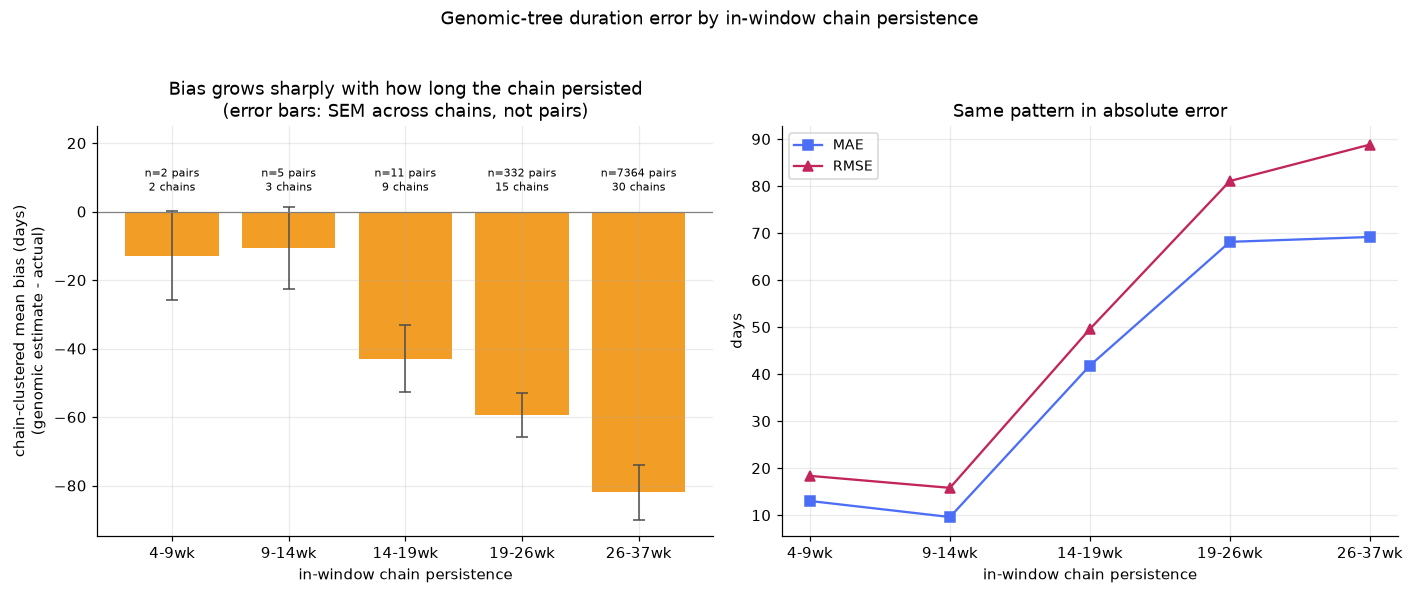

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

ax = axes[0]
x = np.arange(len(err_bins))
bars = ax.bar(x, err_bins.chain_mean_bias_days, color=COL['bias'], alpha=.85,
              yerr=err_bins.chain_bias_sem_days, capsize=4,
              error_kw={'ecolor': '0.3', 'elinewidth': 1})
ax.set_ylim(top=25)  # headroom above the (all-negative) bars for the n= labels
for xi, row in zip(x, err_bins.itertuples()):
    ax.text(xi, 5, f'n={row.n_pairs} pairs\n{row.n_chains} chains', ha='center', va='bottom', fontsize=7.5)
ax.axhline(0, color='0.5', lw=.8)
ax.set_xticks(x)
ax.set_xticklabels(err_bins.duration_bin, rotation=0)
ax.set_xlabel('in-window chain persistence')
ax.set_ylabel('chain-clustered mean bias (days)\n(genomic estimate - actual)')
ax.set_title('Bias grows sharply with how long the chain persisted\n(error bars: SEM across chains, not pairs)')

ax = axes[1]
ax.plot(x, err_bins.mae_days, 's-', color=COL['mae'], label='MAE')
ax.plot(x, err_bins.rmse_days, '^-', color=COL['rmse'], label='RMSE')
ax.set_xticks(x)
ax.set_xticklabels(err_bins.duration_bin, rotation=0)
ax.set_xlabel('in-window chain persistence')
ax.set_ylabel('days')
ax.legend(fontsize=9)
ax.set_title('Same pattern in absolute error')

fig.suptitle('Genomic-tree duration error by in-window chain persistence', y=1.03)
fig.tight_layout()
fig.savefig(f'{cc.RESULTS_DIR}/error_by_duration_bin_windowed.png', bbox_inches='tight')
plt.show()


**Bias grows with persistence, from essentially nothing to nearly three months.** Using the
chain-clustered mean (the statistic the chart actually plots -- averaging each chain once, not each pair):
chains that persisted only 4-9 weeks inside the window show almost no bias (-13 d, 2 chains), rising
through 9-14 weeks (-11 d, 3 chains) and 14-19 weeks (-43 d, 9 chains) to -59 d at 19-26 weeks (15 chains)
and **-82 d for chains that ran nearly the full 36-week window (30 chains)**. That last figure is notably
larger than the simple pair-pooled average (-68 d) -- because pair sampling is capped at 500/chain, a
handful of giant, heavily-resampled chains would otherwise be overweighted relative to chains that only
contributed a few pairs, and here the lightly-sampled long-persistence chains actually have *worse* bias
than the heavily-sampled ones. The chain-clustered number is the one to trust.

**The trend across bins should be read as suggestive, not confirmed statistically** -- the three shortest
bins together hold only 18 pairs from 14 chains, and the wide SEM bars on the left of the chart say so
honestly (13.0, 11.9, and 9.8 days respectively, comparable to the bias estimates themselves). The two
long-persistence bins are on firmer footing: SEM of 6.4 and 8.1 days against biases of -59 and -82 days,
each from 15-30 independent chains. What the data supports without qualification: newly-established chains
(a few weeks into the window) show much less genomic dating bias than chains that have been circulating
for most of the window's 36 weeks. That is exactly the shape you'd expect from deep-branch compression --
error should accumulate with the number of generations / amount of time separating a pair, and persistence
is a proxy for exactly that.


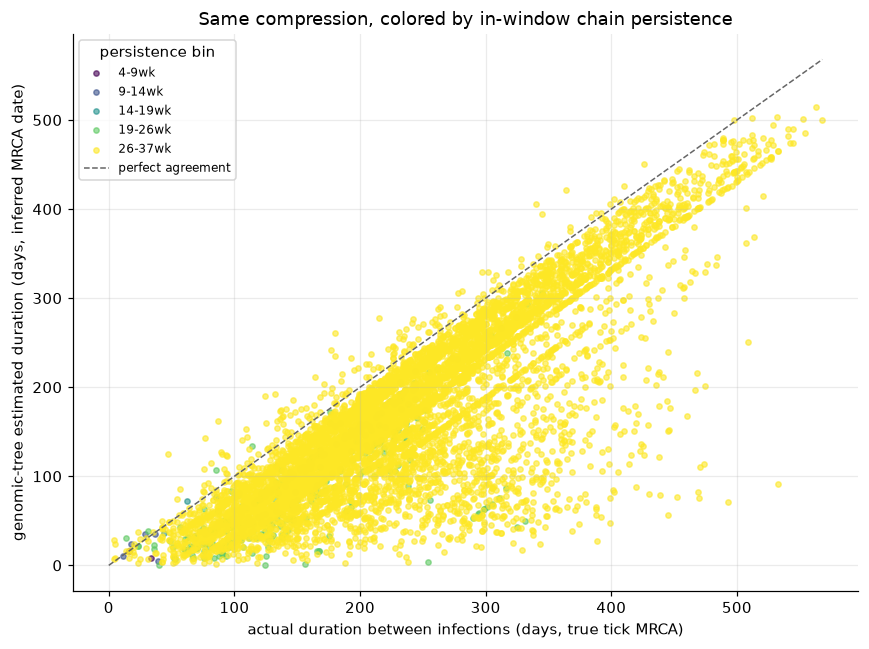

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
bin_colors = plt.get_cmap('viridis')(np.linspace(0, 1, len(BIN_EDGES_WEEKS) - 1))
edges_days = [w * 7 for w in BIN_EDGES_WEEKS]
pair_error_df['duration_bin'] = pd.cut(pair_error_df['windowed_duration_days'], bins=edges_days,
                                        labels=err_bins['duration_bin'].astype(str), include_lowest=True)
for label, colr in zip(err_bins['duration_bin'].astype(str), bin_colors):
    sub = pair_error_df[pair_error_df['duration_bin'] == label]
    ax.scatter(sub.actual_duration_days, sub.genomic_duration_days, s=12, alpha=.6, color=colr, label=label)
lim = max(pair_error_df.actual_duration_days.max(), pair_error_df.genomic_duration_days.max())
ax.plot([0, lim], [0, lim], '--', color='0.4', lw=1, label='perfect agreement')
ax.set_xlabel('actual duration between infections (days, true tick MRCA)')
ax.set_ylabel('genomic-tree estimated duration (days, inferred MRCA date)')
ax.set_title('Same compression, colored by in-window chain persistence')
ax.legend(fontsize=8, title='persistence bin', loc='upper left')
fig.tight_layout()
fig.savefig(f'{cc.RESULTS_DIR}/duration_error_scatter_by_bin.png', bbox_inches='tight')
plt.show()


### 5b. Is persistence really the driver, or just a proxy for transmission generations?

The hypothesis: a chain that has persisted longer in the window probably also contains pairs that are
*genuinely* further apart in the transmission tree -- more intervening infections, hence more accumulated
divergence for TreeTime to compress. `chain_capture_data.lca_with_distances` gets this for free as a
byproduct of the same parent-pointer walk used for the duration calculation: `n_transmission_events` is the
number of real person-to-person infections separating the pair (their distance to the epi MRCA, summed
over both endpoints) -- a direct count of intervening nodes on the transmission tree, independent of how
much calendar time it took.


In [15]:
print('n_transmission_events, all pairs:')
display(pair_error_df['n_transmission_events'].describe())

print(f"\ncorrelation(n_transmission_events, actual_duration_days) = "
      f"{pair_error_df['n_transmission_events'].corr(pair_error_df['actual_duration_days']):.3f}")

print('\nn_transmission_events by persistence bin:')
display(pair_error_df.groupby('duration_bin', observed=True)['n_transmission_events']
        .describe()[['count', 'mean', '50%', 'min', 'max']])

print('\nwithin-bin correlation(n_transmission_events, error_days):')
for label in err_bins['duration_bin'].astype(str):
    sub = pair_error_df[pair_error_df['duration_bin'] == label]
    if len(sub) >= 3:
        r = sub['n_transmission_events'].corr(sub['error_days'])
        print(f'  {label:>8s}: r={r:+.3f}  (n={len(sub)} pairs)')
    else:
        print(f'  {label:>8s}: n={len(sub)} pairs, too few for a correlation')


n_transmission_events, all pairs:


count    7714.000000
mean       35.496630
std        14.673588
min         1.000000
25%        24.000000
50%        34.000000
75%        45.000000
max        91.000000
Name: n_transmission_events, dtype: float64


correlation(n_transmission_events, actual_duration_days) = 0.987

n_transmission_events by persistence bin:


,count,mean,50%,min,max
duration_bin,,,,,
4-9wk,2.0,5.000000,5.0,3.0,7.0
9-14wk,5.0,4.800000,5.0,2.0,7.0
14-19wk,11.0,14.181818,13.0,8.0,22.0
19-26wk,332.0,24.509036,22.0,3.0,55.0
26-37wk,7364.0,36.052960,34.0,1.0,91.0



within-bin correlation(n_transmission_events, error_days):
     4-9wk: n=2 pairs, too few for a correlation
    9-14wk: r=-0.575  (n=5 pairs)
   14-19wk: r=-0.841  (n=11 pairs)
   19-26wk: r=-0.433  (n=332 pairs)
   26-37wk: r=-0.226  (n=7364 pairs)


**Generations and calendar duration are nearly the same variable here** (r=0.99 pooled) -- the
simulation's generation interval is consistent enough that "how many transmission events separate a pair"
and "how many days separate a pair" carry almost identical information. That's *why* persistence and
generation count tell the same story: persistence is already a good proxy for tree depth in this dataset.
It also means the multi-panel view below will mostly recolor the existing x-axis rather than reveal an
independent signal -- worth seeing directly rather than assuming.

The more interesting number is the *within-bin* correlation between generation count and signed error:
consistently negative (more generations -> more negative, i.e. more compressed, bias) in every bin with
enough pairs to check, strongest at 14-19 weeks (r=-0.84, though only 11 pairs) and still present even in
the 26-37 week bin's 7,364 pairs (r=-0.23) where persistence itself has already leveled off. So even within
a fixed persistence category, pairs that happen to be more generations apart show worse compression --
generation count is doing real, independent work, not just riding along with calendar time.


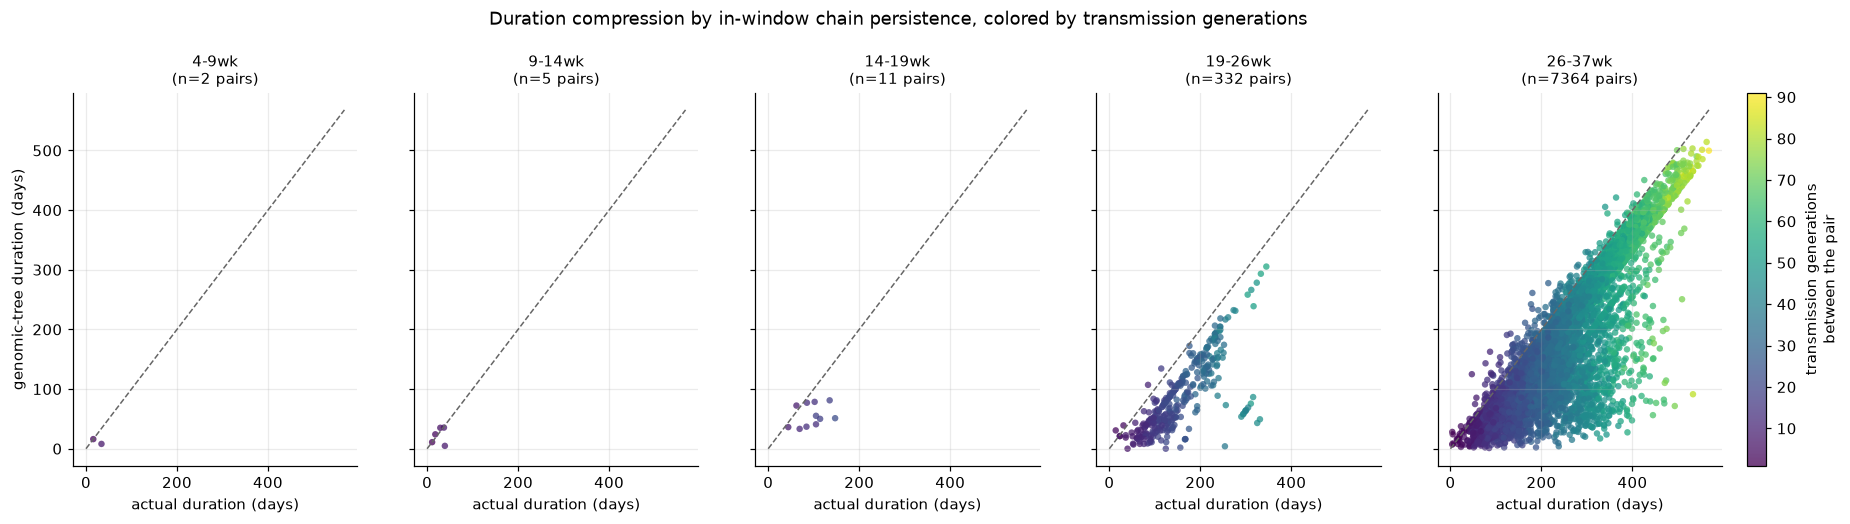

In [16]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4.4), sharex=True, sharey=True)

vmin, vmax = pair_error_df['n_transmission_events'].min(), pair_error_df['n_transmission_events'].max()
lim = max(pair_error_df.actual_duration_days.max(), pair_error_df.genomic_duration_days.max())

sm = None
for ax, label in zip(axes, err_bins['duration_bin'].astype(str)):
    sub = pair_error_df[pair_error_df['duration_bin'] == label]
    sm = ax.scatter(sub.actual_duration_days, sub.genomic_duration_days,
                     c=sub.n_transmission_events, cmap='viridis', vmin=vmin, vmax=vmax,
                     s=18, alpha=.75, edgecolor='none')
    ax.plot([0, lim], [0, lim], '--', color='0.4', lw=1)
    ax.set_title(f'{label}\n(n={len(sub)} pairs)', fontsize=9.5)
    ax.set_xlabel('actual duration (days)')

axes[0].set_ylabel('genomic-tree duration (days)')
cbar = fig.colorbar(sm, ax=axes.tolist(), fraction=0.018, pad=0.015)
cbar.set_label('transmission generations\nbetween the pair')

fig.suptitle('Duration compression by in-window chain persistence, colored by transmission generations', y=1.05)
fig.savefig(f'{cc.RESULTS_DIR}/duration_error_by_bin_and_generations.png', bbox_inches='tight')
plt.show()


Reading left to right: the color gradient inside each panel runs the same direction as position along
the diagonal, confirming the near-collinearity above -- there's no panel where a pair sits far from the
bulk of its color-mates. But the *panels themselves* tell the generation story: the leftmost (short
persistence) panels are colored uniformly dark (few generations, values 2-22 across the first three
panels combined), while 19-26wk and 26-37wk range all the way up to 55 and 91 generations respectively.
Chains that have persisted through most of the window really do connect pairs that are, in a very literal
sense, further apart in transmission history -- and that's the quantity the phylogeny is failing to date
correctly, more than calendar time is per se.


### 5c. Categorizing pairs directly by transmission generations

Section 5b showed generation count doing real work even within a fixed persistence bin. Here's the more
direct cut: skip persistence entirely and categorize pairs by `n_transmission_events` itself, in bins of 5
generations -- the same bar-plot style as Section 5's first figure, but on this axis instead. Alongside the
usual absolute bias/MAE/RMSE (in days), each bin also gets a **percent-of-actual-duration** version
(`error_days / actual_duration_days`), since pairs that are more generations apart are also mechanically
separated by more real time -- percent error is what's left after dividing that out.


In [17]:
GEN_BIN_EDGES = list(range(0, 96, 5))
err_gen_bins = cc.error_by_count_bin(pair_error_df, GEN_BIN_EDGES, col='n_transmission_events')
err_gen_bins.to_csv(f'{cc.RESULTS_DIR}/error_by_generation_bin.csv', index=False)
display(err_gen_bins[['count_bin', 'n_pairs', 'n_chains', 'chain_mean_bias_days', 'chain_bias_sem_days',
                       'mae_days', 'rmse_days', 'chain_mean_bias_pct', 'chain_bias_pct_sem',
                       'mape_pct', 'median_abs_pct_error']].round(2))


,count_bin,n_pairs,n_chains,chain_mean_bias_days,chain_bias_sem_days,mae_days,rmse_days,chain_mean_bias_pct,chain_bias_pct_sem,mape_pct,median_abs_pct_error
0,0-5,30,16,-1.53,2.53,9.37,13.79,16.11,18.09,67.15,30.00
1,5-10,95,36,-22.41,2.87,24.29,29.04,-41.73,5.25,45.29,44.84
2,10-15,394,37,-41.34,3.26,40.71,45.08,-48.23,3.71,48.91,49.86
3,15-20,752,36,-54.82,2.78,52.92,58.19,-47.94,2.61,46.25,46.75
4,20-25,836,35,-65.91,4.68,59.20,66.77,-43.38,2.91,40.33,39.68
5,25-30,971,29,-67.75,5.23,62.68,73.25,-36.62,2.74,34.38,30.54
6,30-35,1112,27,-82.00,8.00,65.16,77.83,-36.59,3.20,30.19,25.84
7,35-40,846,27,-105.33,10.91,77.30,94.54,-41.53,4.07,31.02,26.43
8,40-45,806,23,-121.06,14.20,85.62,109.52,-41.69,4.62,30.14,21.72
9,45-50,646,21,-140.59,19.29,89.59,117.88,-43.33,5.66,28.35,19.06


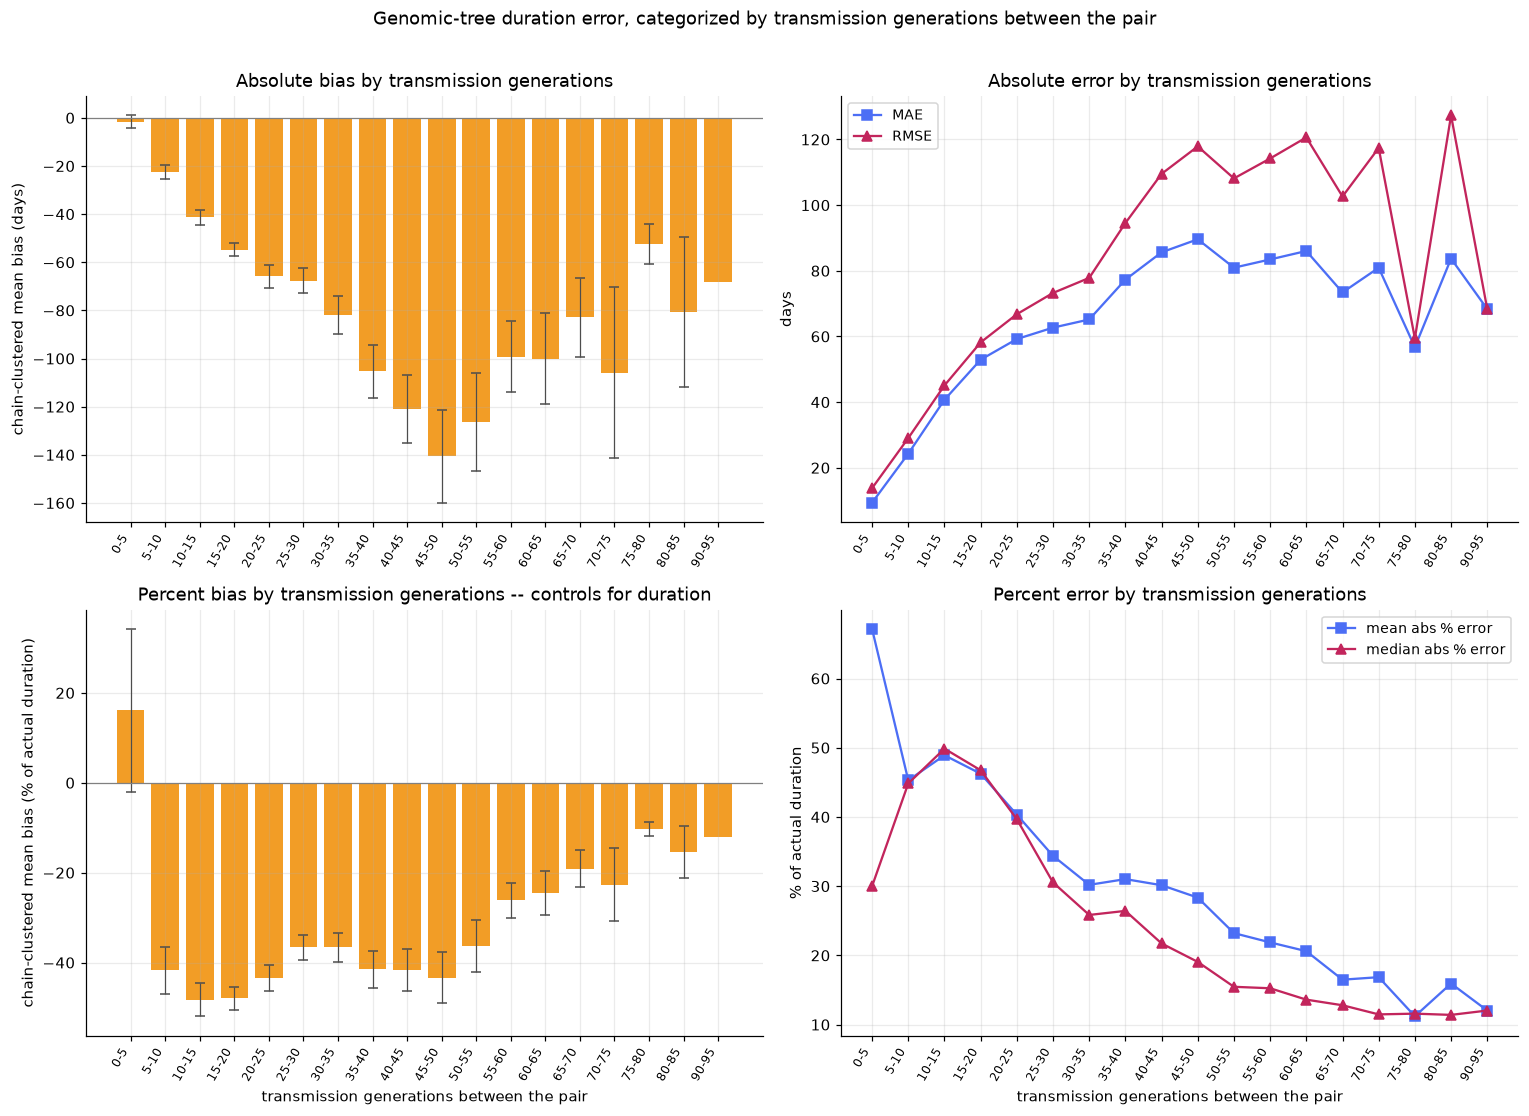

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
x = np.arange(len(err_gen_bins))
xlabels = err_gen_bins['count_bin'].astype(str)

ax = axes[0, 0]
ax.bar(x, err_gen_bins.chain_mean_bias_days, color=COL['bias'], alpha=.85,
       yerr=err_gen_bins.chain_bias_sem_days, capsize=3, error_kw={'ecolor': '0.3', 'elinewidth': .8})
ax.axhline(0, color='0.5', lw=.8)
ax.set_xticks(x); ax.set_xticklabels(xlabels, rotation=60, ha='right', fontsize=8)
ax.set_ylabel('chain-clustered mean bias (days)')
ax.set_title('Absolute bias by transmission generations')

ax = axes[0, 1]
ax.plot(x, err_gen_bins.mae_days, 's-', color=COL['mae'], label='MAE')
ax.plot(x, err_gen_bins.rmse_days, '^-', color=COL['rmse'], label='RMSE')
ax.set_xticks(x); ax.set_xticklabels(xlabels, rotation=60, ha='right', fontsize=8)
ax.set_ylabel('days')
ax.legend(fontsize=9)
ax.set_title('Absolute error by transmission generations')

ax = axes[1, 0]
ax.bar(x, err_gen_bins.chain_mean_bias_pct, color=COL['bias'], alpha=.85,
       yerr=err_gen_bins.chain_bias_pct_sem, capsize=3, error_kw={'ecolor': '0.3', 'elinewidth': .8})
ax.axhline(0, color='0.5', lw=.8)
ax.set_xticks(x); ax.set_xticklabels(xlabels, rotation=60, ha='right', fontsize=8)
ax.set_xlabel('transmission generations between the pair')
ax.set_ylabel('chain-clustered mean bias (% of actual duration)')
ax.set_title('Percent bias by transmission generations -- controls for duration')

ax = axes[1, 1]
ax.plot(x, err_gen_bins.mape_pct, 's-', color=COL['mae'], label='mean abs % error')
ax.plot(x, err_gen_bins.median_abs_pct_error, '^-', color=COL['rmse'], label='median abs % error')
ax.set_xticks(x); ax.set_xticklabels(xlabels, rotation=60, ha='right', fontsize=8)
ax.set_xlabel('transmission generations between the pair')
ax.set_ylabel('% of actual duration')
ax.legend(fontsize=9)
ax.set_title('Percent error by transmission generations')

fig.suptitle('Genomic-tree duration error, categorized by transmission generations between the pair', y=1.01)
fig.tight_layout()
fig.savefig(f'{cc.RESULTS_DIR}/error_by_generation_bin.png', bbox_inches='tight')
plt.show()


**Controlling for duration flips the story.** In absolute terms, bias grows with generation count as
before -- from essentially nothing at 0-5 generations to a peak of about -141 days (chain-clustered) around
45-50 generations -- then plateaus and even eases slightly at the (small-N, noisy) high end. But **percent
error tells the opposite tale at the top end**: mean/median absolute percent error *peaks* at 10-20
generations (~46-50% of the true duration) and then declines steadily to just ~11-17% by 65+ generations
(bottom-right panel). The pairs separated by the most transmission events have the largest errors in days,
but those errors are a *smaller share* of an even-larger true separation -- proportionally, the genomic
tree is actually **more** accurate for the most deeply-diverged pairs, not less.

**The real problem zone is the low-to-middle range, not the extremes.** 10-50 generations (roughly what
populates the 19-26 and 26-37 week persistence bins from Section 5) is where relative error is worst
(35-50%). Very close pairs (0-5 generations, 30 pairs / 16 chains) even flip sign -- a small **positive**
mean bias (+16%, but a wide interval crossing zero: [-2%, +34%]) -- suggesting the tree may slightly
*overestimate* separation for near-identical sequences, the opposite failure mode from everywhere else.
That bin is thin enough (16 chains) to be a real but tentative signal rather than a settled finding.

**Practical read:** if the goal is picking which genomic-tree duration estimates to trust, generation count
(or its proxy, chain persistence) is informative but not in a single direction -- short-separation pairs
carry a small possible over-estimate, medium-separation pairs (10-50 generations) carry the largest
*relative* under-estimate, and the most deeply-diverged pairs are relatively (if not absolutely) the most
reliable. A single global correction factor (like the -68 day / -32% headline figures from Section 5) would
under-correct the 10-50 generation range and over-correct everything past ~65 generations.

### Caveats specific to this cut

- **The tail bins are thin.** 70-95 generations combine for only 124 pairs across 15 chains, and 90-95 is a
  single pair/chain -- its point estimate carries no more weight than an anecdote, and the RMSE panel's
  sawtooth at the far right is exactly that instability, not a real oscillation.
- **Percent error's denominator is a real quantity (min 4 days), not a nuisance,** but it does mean a pair
  with a small true separation and any absolute miss produces a large percent swing -- the max observed was
  +603%. `median_abs_pct_error` is reported alongside `mape_pct` for exactly that reason and is the more
  robust number to quote.


## 8. Cross-chain genomic linkages: where the phylogeny groups unrelated chains together

Every pair sampled so far in this notebook has come from *within* a single transmission chain --
`sample_pairs_per_component` only ever draws two tips that share a real transmission ancestor. But `gen_G`
is a single rooted tree spanning every sequenced tip regardless of chain, so somewhere in it, tips from
different, causally disconnected chains (different weakly-connected components of `epi_G`, sharing zero
transmission edges) necessarily sit under a shared inferred ancestor. That's the phylogeny linking a sample
to a chain it was never actually a member of.

Two things are expected going in:
- Some of this is unavoidable and uninformative on its own: this is a *single* tree, so every pair of the
  121 sequenced chains has *some* common ancestor in it -- that alone says nothing about the tree doing
  anything wrong.
- What's actually informative is *how shallow* each meeting point is. A merge near the root, combining
  large, well-established clades, just reflects that the whole outbreak shares a common origin. A merge low
  in the tree -- a single tip nested deep inside another chain's clade -- is the more surprising case: it
  says a specific sample looks, genetically, more like an unrelated chain's circulating diversity than like
  the rest of its own chain.

Method: walk the tree bottom-up, and at every internal node ask whether two of its own children's
descendant tip sets belong to disjoint sets of chains. Wherever they do, that node is (one of, possibly
several, if a chain's samples aren't monophyletic) the point where those two chains' sampled lineages first
become indistinguishable in the phylogeny.


In [19]:
t0 = time.time()
tip_chain = {gname: node_to_component[epi_node] for gname, epi_node in gen_to_epi.items()}
tick_of_gen_leaf = {gname: epi_tick[epi_node] for gname, epi_node in gen_to_epi.items()}

_, gen_children_of, gen_root = cc.build_gen_tree_indices(gen_G)
gen_order = cc.gen_postorder(gen_children_of, gen_root)
merges_df, gen_node_stats = cc.compute_chain_merges(
    gen_children_of, gen_order, tip_chain, tick_of_gen_leaf, gen_num_date
)
merges_df = cc.annotate_merge_earliest(merges_df, tip_chain, tick_of_gen_leaf)
print(f"[{time.time()-t0:.0f}s] {len(merges_df):,} (node, chain_a, chain_b) rows across "
      f"{merges_df['node'].nunique():,} distinct merge nodes")

chain_tip_counts = pd.Series(tip_chain).value_counts()
print(f"{len(chain_tip_counts)} of {len(component_df):,} chains have >=1 sequenced tip; "
      f"{(chain_tip_counts==1).sum()} are represented by exactly one sequenced tip")

merges_df.drop(columns=['tips_a', 'tips_b']).to_csv(f'{cc.RESULTS_DIR}/cross_chain_merges.csv', index=False)


[0s] 9,022 (node, chain_a, chain_b) rows across 478 distinct merge nodes
121 of 7,550 chains have >=1 sequenced tip; 62 are represented by exactly one sequenced tip


In [20]:
tip_demo = cc.load_tip_demographics()
n_age_known = sum(1 for v in tip_demo.values() if v['age_band'] is not None)
n_county_known = sum(1 for v in tip_demo.values() if v['county'] is not None)
print(f"tip demographics loaded from the augur run's own metadata: age known for {n_age_known:,}, "
      f"county known for {n_county_known:,} (of {len(tip_demo):,} tips, incl. 2 reference leaves with neither)")


tip demographics loaded from the augur run's own metadata: age known for 14,791, county known for 14,791 (of 14,793 tips, incl. 2 reference leaves with neither)


`merges_df` covers all C(121,2) = 7,260 possible chain pairs -- confirming every sampled chain pair does
meet *somewhere*, which, as flagged above, isn't itself informative; a single node combining two large,
diverse subtrees produces many pair-rows at once from one structural event. The meaningful unit is the
**node**, not the pair -- collapsing to that view next.


478 of 14,187 internal nodes host a cross-chain merge (3.4%)
pure cherries (two individual tips from two different chains, directly sister): 10


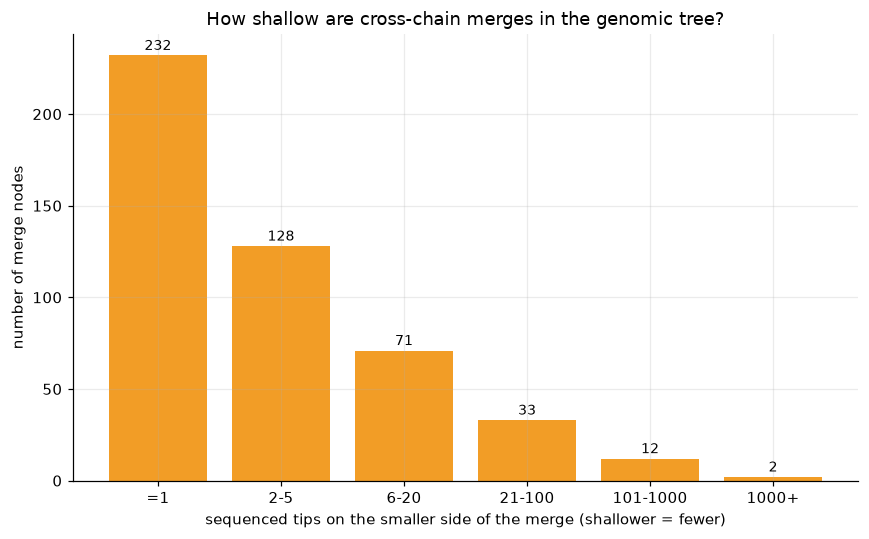

In [21]:
node_summary = cc.summarize_merge_nodes(merges_df)
bin_edges = [0, 1, 5, 20, 100, 1000, 100_000]
bin_labels = ['=1', '2-5', '6-20', '21-100', '101-1000', '1000+']
node_summary['size_bin'] = pd.cut(node_summary['smallest_side_tips'], bins=bin_edges, labels=bin_labels)

n_internal = sum(1 for n in gen_G.nodes if gen_G.out_degree(n) > 0)
print(f"{len(node_summary):,} of {n_internal:,} internal nodes host a cross-chain merge "
      f"({100*len(node_summary)/n_internal:.1f}%)")
print(f"pure cherries (two individual tips from two different chains, directly sister): "
      f"{node_summary['is_pure_cherry'].sum()}")

fig, ax = plt.subplots(figsize=(8, 5))
counts = node_summary['size_bin'].value_counts().reindex(bin_labels)
ax.bar(bin_labels, counts.values, color=COL['bias'], alpha=.85)
for i, v in enumerate(counts.values):
    ax.text(i, v + 3, str(v), ha='center', fontsize=9)
ax.set_xlabel('sequenced tips on the smaller side of the merge (shallower = fewer)')
ax.set_ylabel('number of merge nodes')
ax.set_title('How shallow are cross-chain merges in the genomic tree?')
fig.tight_layout()
fig.savefig(f'{cc.RESULTS_DIR}/cross_chain_merge_depth.png', bbox_inches='tight')
plt.show()


**Half of all merge nodes are as shallow as possible -- a single sequenced tip sitting directly against
something else.** 232 of 478 merge nodes (49%) have a smallest side of exactly one tip; another 128 have
2-5. Only 14 are genuinely deep, root-adjacent combinations of large, established clades (101+ tips on the
smaller side). So under a literal reading of "how many places does this tree link two different
transmission chains," almost all of them are one lone tip meeting something else -- not a handful of big
clades merging near the origin.

10 of the 478 are the starkest possible case: a literal cherry, two individual sequenced tips from two
different chains, direct sisters with nothing else nested between them.


In [22]:
cherry_nodes = node_summary.loc[node_summary['is_pure_cherry'], 'node']
cherries = merges_df[
    merges_df['node'].isin(cherry_nodes) & (merges_df['n_tips_a'] == 1) & (merges_df['n_tips_b'] == 1)
].copy()
cherries['age_group_a'] = cherries['tips_a'].map(lambda t: tip_demo.get(t[0], {}).get('age_group'))
cherries['age_group_b'] = cherries['tips_b'].map(lambda t: tip_demo.get(t[0], {}).get('age_group'))
cherries['county_a'] = cherries['tips_a'].map(lambda t: tip_demo.get(t[0], {}).get('county'))
cherries['county_b'] = cherries['tips_b'].map(lambda t: tip_demo.get(t[0], {}).get('county'))
display(cherries[['node', 'chain_a', 'chain_b', 'num_date', 'age_group_a', 'age_group_b',
                   'county_a', 'county_b', 'a_is_earliest', 'b_is_earliest']]
        .sort_values('num_date').reset_index(drop=True))


,node,chain_a,chain_b,num_date,age_group_a,age_group_b,county_a,county_b,a_is_earliest,b_is_earliest
0,NODE_0004467,503,1192,2021.465,Older adult (50-64),Older adult (50-64),Fairfax VA,Franklin VA,1.0,1.0
1,NODE_0000805,746,917,2021.533,Student (5-17),Older adult (50-64),Lancaster VA,Gloucester VA,1.0,1.0
2,NODE_0001256,508,1190,2021.604,Student (5-17),Older adult (50-64),Tazewell VA,Roanoke VA,1.0,1.0
3,NODE_0000616,675,1604,2021.604,Senior (65+),Student (5-17),Suffolk City VA,Chesterfield VA,1.0,1.0
4,NODE_0003509,240,2182,2021.681,Student (5-17),Adult (18-49),Richmond City VA,Henrico VA,0.0,1.0
5,NODE_0001245,931,3099,2021.759,Older adult (50-64),Senior (65+),Wythe VA,Fairfax VA,1.0,1.0
6,NODE_0006233,164,2882,2021.889,Adult (18-49),Adult (18-49),Chesterfield VA,Arlington VA,0.0,0.0
7,NODE_0003701,240,2268,2021.974,Older adult (50-64),Adult (18-49),Greensville VA,Richmond City VA,0.0,1.0
8,NODE_0000077,562,3690,2021.999,Older adult (50-64),Student (5-17),Virginia Beach City VA,Norfolk City VA,0.0,1.0
9,NODE_0009345,164,2248,2022.041,Older adult (50-64),Student (5-17),Roanoke City VA,Chesapeake City VA,0.0,1.0


### Is a cross-chain linkage typically that chain's earliest sequenced sample?

The intuition is that early in an outbreak, before within-chain diversity has built up, a chain's first few
sequenced samples should look genetically similar to whatever else was circulating at the time -- so a
lone, misleadingly-placed tip should typically be that chain's *earliest* sample, not a later one. Testing
this means separating two very different situations that both look like "a lone tip merging elsewhere":

- a chain with **only one sequenced tip, ever** (62 of the 121, per the skew noted above) -- "is this the
  earliest sample" is a tautology here, since it's the *only* sample.
- a chain with multiple sequenced tips, one of which shows up as an outlier detached from the rest of its
  own chain's diversity -- this is the meaningful test.


In [23]:
merge_events = cc.classify_merge_anchors(merges_df, tip_chain)
singleton_events = merge_events[merge_events['is_singleton_chain']]
multi_events = merge_events[~merge_events['is_singleton_chain']]

print(f"{len(merge_events)} distinct (node, chain) lone-tip events total")
print(f"  {len(singleton_events)} are genuine singleton chains (tautologically 'earliest' -- their only sample)")
print(f"  {len(multi_events)} are multi-tip chains caught as a lone outlier, across "
      f"{multi_events['chain'].nunique()} distinct chains: {sorted(multi_events['chain'].unique())}")

determinable = multi_events['is_earliest'].dropna()
n_earliest = int((determinable == 1).sum())
print(f"\nof these {len(determinable)} multi-tip outlier events, "
      f"{n_earliest} ({determinable.mean():.1%}) are that chain's actual earliest sample")

lag = (multi_events.loc[multi_events['is_earliest'] == 0, 'min_tick']
       - multi_events.loc[multi_events['is_earliest'] == 0, 'chain_earliest_tick'])
print(f"when NOT earliest: tick-lag behind the chain's true earliest sample -- "
      f"mean {lag.mean():.1f}d, median {lag.median():.1f}d, max {lag.max():.0f}d")

multi_events.to_csv(f'{cc.RESULTS_DIR}/cross_chain_outlier_events.csv', index=False)
display(multi_events.groupby('chain').agg(n_events=('node', 'size'), n_earliest=('is_earliest', 'sum')))


242 distinct (node, chain) lone-tip events total
  62 are genuine singleton chains (tautologically 'earliest' -- their only sample)
  180 are multi-tip chains caught as a lone outlier, across 7 distinct chains: [np.int64(136), np.int64(164), np.int64(187), np.int64(240), np.int64(562), np.int64(1859), np.int64(2882)]

of these 180 multi-tip outlier events, 1 (0.6%) are that chain's actual earliest sample
when NOT earliest: tick-lag behind the chain's true earliest sample -- mean 87.4d, median 73.0d, max 254d


,n_events,n_earliest
chain,,
136,6,0.0
164,117,0.0
187,9,0.0
240,29,0.0
562,16,0.0
1859,2,1.0
2882,1,0.0


**This flips the hypothesis.** Among multi-tip chains caught as a lone outlier outside their own main
clade, 179 of 180 (99.4%) are *not* that chain's earliest sample -- almost always a later one, sometimes
substantially so (median 13 days after the chain's true earliest tick, worst case 254 days). And it's
concentrated in just seven chains -- 136, 164, 187, 240, 562, 1859, 2882 -- most of which are the largest,
longest-running, most heavily sequenced chains in the whole dataset (chain 164 alone supplies 69% of all
sequenced tips).

That pattern fits a different, more mundane mechanism than "early samples are ambiguous": a chain that has
circulated and diversified for months, with hundreds to thousands of closely-related co-circulating
sequences, gives TreeTime very little branch length to work with when placing any individual *later*
sample -- a handful of them, out of thousands, end up placed as apparent outliers not because they're
genuinely close to another chain, but because there's too little residual signal left to pin them
confidently to their own chain's crowded, low-diversity clade. Sparse chains (including all 62 true
singletons) don't have this problem, but also can't be tested against it -- they have no internal diversity
to place a tip "wrong" relative to.


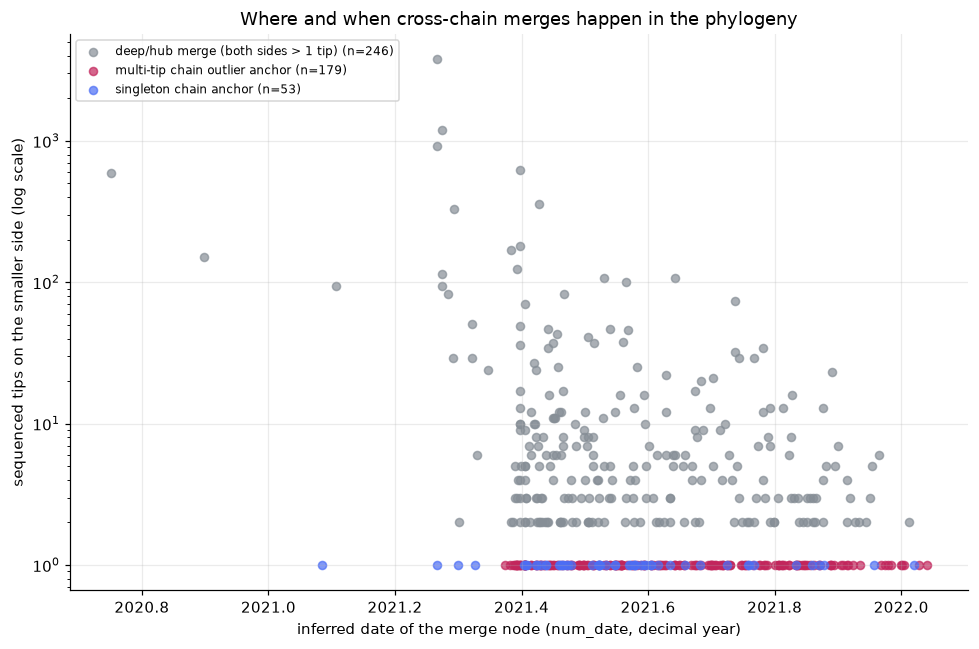

In [24]:
has_singleton = set(singleton_events['node'])
has_multi_outlier = set(multi_events['node'])

def _classify(node):
    if node in has_multi_outlier:
        return 'multi-tip chain outlier anchor'
    if node in has_singleton:
        return 'singleton chain anchor'
    return 'deep/hub merge (both sides > 1 tip)'

node_summary['category'] = node_summary['node'].map(_classify)
cat_colors = {'deep/hub merge (both sides > 1 tip)': '#868E96',
              'singleton chain anchor': COL['total'],
              'multi-tip chain outlier anchor': COL['zero']}

fig, ax = plt.subplots(figsize=(9, 6))
for cat, sub in node_summary.groupby('category'):
    ax.scatter(sub['num_date'], sub['smallest_side_tips'].clip(lower=0.8), s=28, alpha=.7,
               color=cat_colors.get(cat, '0.5'), label=f'{cat} (n={len(sub)})')
ax.set_yscale('log')
ax.set_xlabel('inferred date of the merge node (num_date, decimal year)')
ax.set_ylabel('sequenced tips on the smaller side (log scale)')
ax.set_title('Where and when cross-chain merges happen in the phylogeny')
ax.legend(fontsize=8, loc='upper left')
fig.tight_layout()
fig.savefig(f'{cc.RESULTS_DIR}/cross_chain_merge_scatter.png', bbox_inches='tight')
plt.show()


### Seeing one directly: two example linkages in their local tree context

The stats above describe hundreds of merge events in aggregate. To see what one actually looks like, pick a
single cross-chain merge and draw the surrounding tree: climb from that node toward the root while the
ancestor's own subtree stays small (`extract_context_subtree`), then lay out that whole local subtree as a
rectangular phylogram (`compute_tree_layout`) -- x position is each node's own inferred `num_date`, so branch
length reflects inferred time, and every sequenced tip is labeled with its real chain id and simulation tick.

Two contrasting examples, both literal cherries (the cleanest case -- two individual tips, directly sister,
nothing else nested between them), chosen to match the two mechanisms found above:
- an "expected" case where both sides of the cherry *are* their chain's own earliest sequenced sample.
- a "surprising" case where the outlier side is *not* -- one of the seven flagged chains contributing a
  later sample that lands elsewhere in the tree.


In [25]:
n_tips_of_node = dict(zip(gen_node_stats['node'], gen_node_stats['n_tips']))
cherry_nodes_set = set(node_summary.loc[node_summary['is_pure_cherry'], 'node'])
cherry_rows = merges_df[
    merges_df['node'].isin(cherry_nodes_set) & (merges_df['n_tips_a'] == 1) & (merges_df['n_tips_b'] == 1)
]

def pick_example(candidates, min_context_tips=8, max_tips=30):
    """First candidate whose climbed-up context subtree reaches
    `min_context_tips` -- some cherries sit directly under a huge (>max_tips)
    clade with nothing smaller to climb to, which would plot as an
    uninformative 2-tip figure with no surrounding context."""
    for _, row in candidates.iterrows():
        anchor = cc.extract_context_subtree(row['node'], gen_children_of, gen_parent,
                                             n_tips_of_node, max_tips=max_tips)
        if n_tips_of_node.get(anchor, 0) >= min_context_tips:
            return row, anchor
    row = candidates.iloc[0]
    return row, cc.extract_context_subtree(row['node'], gen_children_of, gen_parent,
                                            n_tips_of_node, max_tips=max_tips)

expected_candidates = cherry_rows[(cherry_rows.a_is_earliest == 1) & (cherry_rows.b_is_earliest == 1)]
surprising_candidates = cherry_rows[
    (cherry_rows.a_is_earliest == 0) | (cherry_rows.b_is_earliest == 0)
].sort_values('num_date', ascending=False)

expected_row, expected_anchor = pick_example(expected_candidates)
surprising_row, surprising_anchor = pick_example(surprising_candidates)

for label, row, anchor in [('expected', expected_row, expected_anchor),
                            ('surprising', surprising_row, surprising_anchor)]:
    print(f"[{label}] merge node {row['node']}: chain {row['chain_a']} (tick {row['min_tick_a']:.0f}) "
          f"<-> chain {row['chain_b']} (tick {row['min_tick_b']:.0f}), context subtree = "
          f"{n_tips_of_node[anchor]} tips")


[expected] merge node NODE_0001245: chain 931 (tick 413) <-> chain 3099 (tick 367), context subtree = 27 tips
[surprising] merge node NODE_0009345: chain 164 (tick 424) <-> chain 2248 (tick 422), context subtree = 16 tips


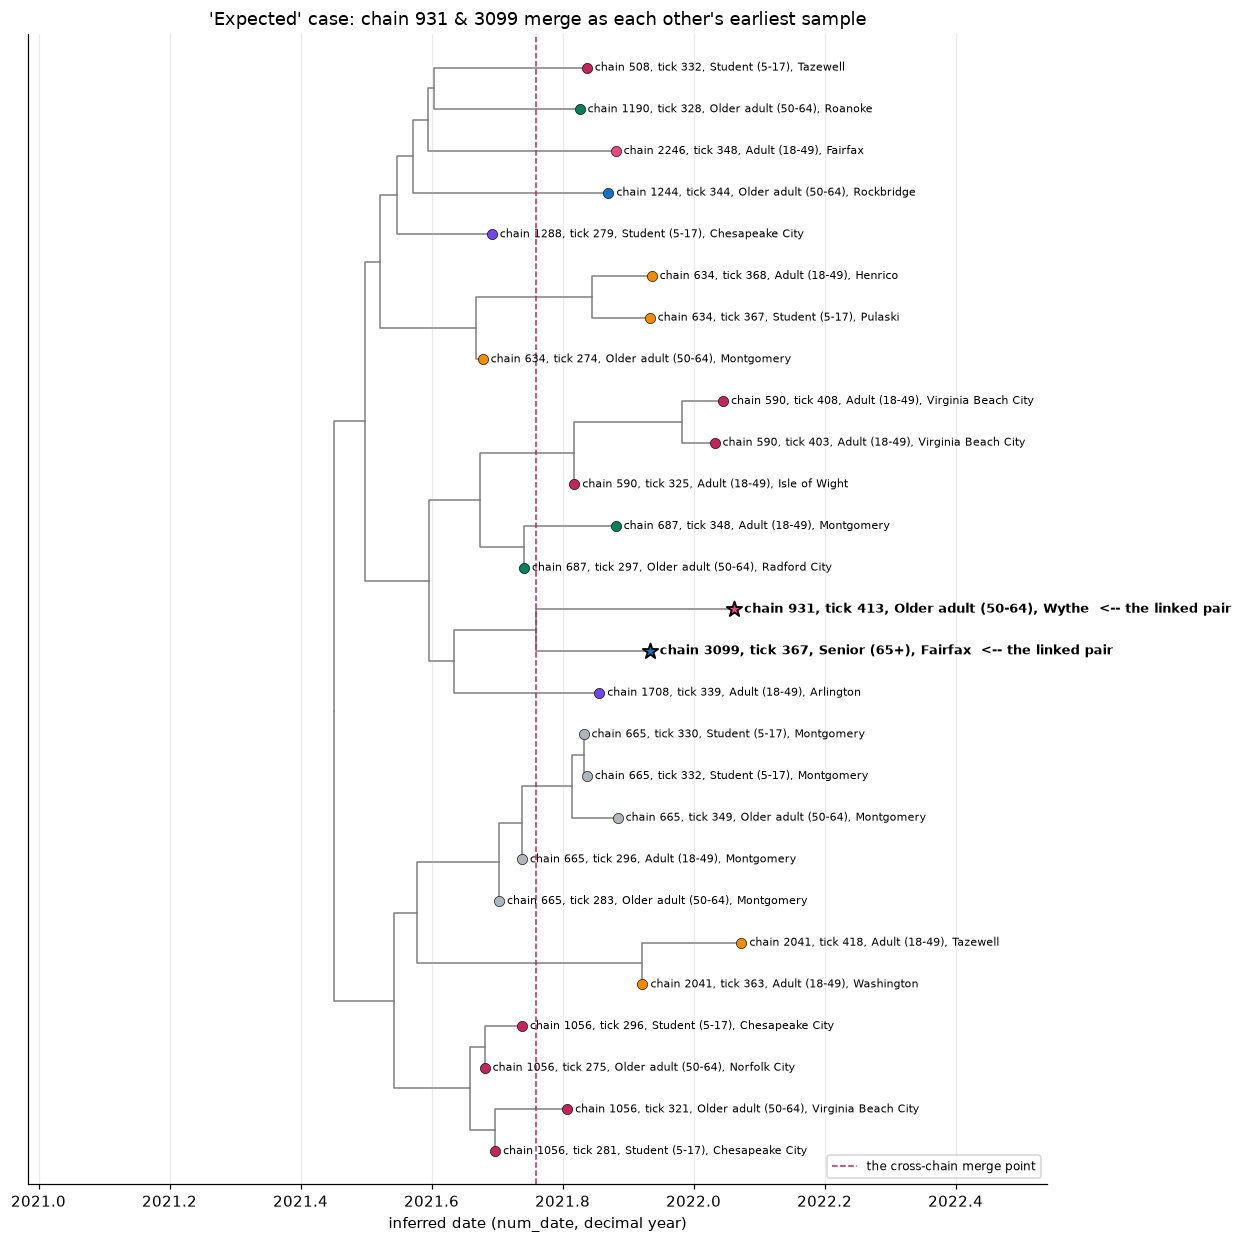

host chain in this local view: 665, other chains present: [1056, 2041, 1708, 3099, 931, 687, 590, 634, 1288, 1244, 2246, 1190, 508]


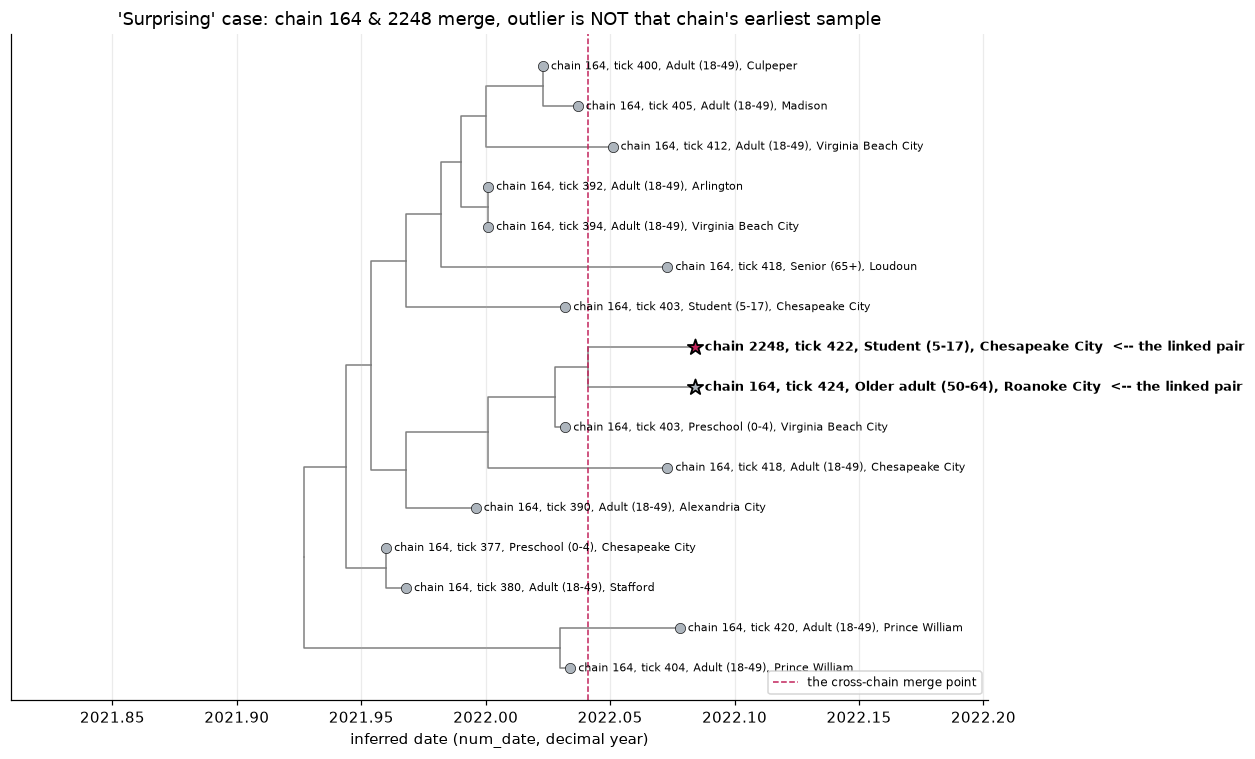

host chain in this local view: 164, other chains present: [2248]


In [26]:
def plot_context_subtree(anchor, merge_node, highlight_tips, title, save_name):
    pos, edges, leaves = cc.compute_tree_layout(anchor, gen_children_of, gen_num_date)
    subtree_chains = Counter(tip_chain.get(l) for l in leaves)
    host_chain = subtree_chains.most_common(1)[0][0]
    palette = ['#C2255C', '#F08C00', '#7048E8', '#1971C2', '#E64980', '#087F5B']
    other_chains = [c for c in subtree_chains if c != host_chain]
    chain_color = {host_chain: '#ADB5BD'}
    for i, c in enumerate(other_chains):
        chain_color[c] = palette[i % len(palette)]

    fig, ax = plt.subplots(figsize=(11.5, max(3, 0.4 * len(leaves)) + 0.6))
    for p, c in edges:
        x0, y0 = pos[p]; x1, y1 = pos[c]
        ax.plot([x0, x0, x1], [y0, y1, y1], color='0.5', lw=1, zorder=1)
    ax.axvline(gen_num_date[merge_node], color=COL['zero'], ls='--', lw=1, zorder=2,
               label='the cross-chain merge point')

    for leaf in leaves:
        x, y = pos[leaf]
        cid = tip_chain.get(leaf)
        tick = tick_of_gen_leaf.get(leaf)
        is_hl = leaf in highlight_tips
        demo = tip_demo.get(leaf, {})
        age_str = demo.get('age_group') or 'age ?'
        county_str = (demo.get('county') or 'county ?').replace(' VA', '')
        base = f'chain {cid}, tick {tick}, {age_str}, {county_str}' if cid is not None else str(leaf)
        label = base + ('  <-- the linked pair' if is_hl else '')
        ax.scatter([x], [y], color=chain_color.get(cid, '0.7'), s=110 if is_hl else 45,
                   zorder=4 if is_hl else 3, marker='*' if is_hl else 'o',
                   edgecolor='black', linewidth=1.2 if is_hl else 0.4)
        ax.text(x, y, '  ' + label, va='center', fontsize=8.5 if is_hl else 7.5,
                fontweight='bold' if is_hl else 'normal')

    ax.set_yticks([])
    ax.set_ylim(-0.8, len(leaves) - 0.2)
    ax.margins(x=0.75)
    ax.set_xlabel('inferred date (num_date, decimal year)')
    ax.set_title(title)
    ax.legend(fontsize=8, loc='lower right')
    fig.tight_layout()
    fig.savefig(f'{cc.RESULTS_DIR}/{save_name}', bbox_inches='tight')
    plt.show()
    return host_chain, other_chains

exp_host, exp_others = plot_context_subtree(
    expected_anchor, expected_row['node'], set(expected_row['tips_a']) | set(expected_row['tips_b']),
    f"'Expected' case: chain {expected_row['chain_a']} & {expected_row['chain_b']} merge as each "
    f"other's earliest sample", 'example_expected_cherry.png',
)
print(f"host chain in this local view: {exp_host}, other chains present: {exp_others}")

sur_host, sur_others = plot_context_subtree(
    surprising_anchor, surprising_row['node'], set(surprising_row['tips_a']) | set(surprising_row['tips_b']),
    f"'Surprising' case: chain {surprising_row['chain_a']} & {surprising_row['chain_b']} merge, "
    f"outlier is NOT that chain's earliest sample", 'example_surprising_cherry.png',
)
print(f"host chain in this local view: {sur_host}, other chains present: {sur_others}")


Reading the two figures: the "expected" case is far richer than a simple pair. Chain 931 and chain 3099's
cherry sits inside a 27-tip local neighborhood built entirely out of **14 wholly-distinct, causally
unconnected chains** -- 508, 1190, 2246, 1244, 1288, 634, 590, 687, 931, 3099, 1708, 665, 2041, and 1056.
Every single sequenced tip any of these 14 chains ever produced is inside this one small clade (e.g. all 5
of chain 665's tips, all 4 of chain 1056's, all 3 of chain 634's). And within it, the tree gets each
individual chain *right* -- chain 634's 3 tips form their own little clade, chain 665's 5 tips form theirs,
chain 1056's 4 tips form theirs -- it's specifically the relationship *between* those correctly-resolved
chain-clades that's wrong: 14 of them, each internally coherent, sit as close siblings of each other
spanning ticks 274-418 (about five months), consistent with many small, independent introductions that
happened to start from a very similar circulating genotype around a similar time, rather than any one of
them being a phylogenetic placement error.

The "surprising" case is the opposite shape: one single tip (chain 2248) sits as sister to one specific
chain-164 tip (tick 424), but that tip is surrounded by *fifteen other* chain-164 tips (ticks 377-420) that
resolve into their own small, well-formed sub-clades just one branch away. There's no shortage of close
relatives for tick-424 to have nested among -- it just didn't. That's the placement-uncertainty story from
above, made concrete: a large, late-window, low-diversity clade gives TreeTime very little to work with, and
individual placements within it are chosen right where two subclades already blur together.


### The chain-by-chain view: how many linkage events per chain, and with how many others

Collapsing `merges_df` per chain instead of per node answers a different question: not "how many places
does the tree cross chains" but "for a given chain, how exposed is *it* specifically" -- does it show up in
one merge or dozens, and is it mixed with a handful of neighbors or with everyone. Counting is deliberately
*not* deduplicated across nodes here (`summarize_chain_linkages`): a chain meeting 40 others at one big hub
node has 40 real linkages from its own point of view, even though that's one structural event by the node
count above. Double-counting across nodes is fine -- the comparison is chain-vs-chain, not event-vs-event.


n_merge_nodes ('events') across 121 sequenced chains: min 2, median 11, max 282 (chain 164)
n_other_chains (unrestricted): every chain shows 120 -- same guaranteed-by-a-single-tree fact as the raw C(121,2) pair count above, viewed per chain; not informative on its own (see below for the fix).


,chain,n_sequenced_tips,n_merge_nodes,n_pair_rows,n_other_chains
1,164,10271,282,1690,120
98,2192,1,72,268,120
102,2248,1,58,254,120
118,3596,1,55,313,120
109,2882,3,55,315,120
4,240,1565,53,211,120
80,1487,1,46,263,120
99,2193,2,46,305,120
103,2266,1,42,238,120
88,1794,2,37,233,120


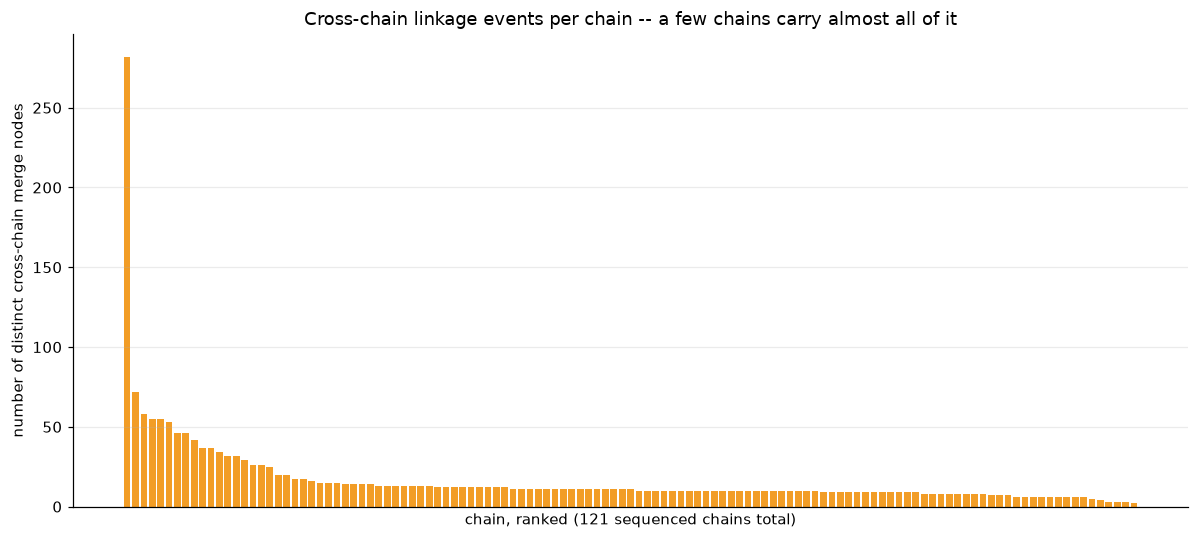

In [27]:
chain_summary = cc.summarize_chain_linkages(merges_df, tip_chain)
top_chain = chain_summary.loc[chain_summary['n_merge_nodes'].idxmax()]
print(f"n_merge_nodes ('events') across {len(chain_summary)} sequenced chains: "
      f"min {chain_summary.n_merge_nodes.min()}, median {chain_summary.n_merge_nodes.median():.0f}, "
      f"max {chain_summary.n_merge_nodes.max()} (chain {int(top_chain['chain'])})")
print(f"n_other_chains (unrestricted): every chain shows {chain_summary['n_other_chains'].iloc[0]} -- "
      "same guaranteed-by-a-single-tree fact as the raw C(121,2) pair count above, viewed per chain; "
      "not informative on its own (see below for the fix).")

display(chain_summary.sort_values('n_merge_nodes', ascending=False)
        [['chain', 'n_sequenced_tips', 'n_merge_nodes', 'n_pair_rows', 'n_other_chains']].head(15))

fig, ax = plt.subplots(figsize=(11, 5))
plot_df = chain_summary.sort_values('n_merge_nodes', ascending=False).reset_index(drop=True)
ax.bar(range(len(plot_df)), plot_df['n_merge_nodes'], color=COL['bias'], alpha=.85)
ax.set_xlabel(f'chain, ranked ({len(plot_df)} sequenced chains total)')
ax.set_ylabel('number of distinct cross-chain merge nodes')
ax.set_title('Cross-chain linkage events per chain -- a few chains carry almost all of it')
ax.set_xticks([])
fig.tight_layout()
fig.savefig(f'{cc.RESULTS_DIR}/chain_linkage_events_ranked.png', bbox_inches='tight')
plt.show()


**`n_other_chains` needs the same fix as the raw pair count above.** Restricting to *shallow* merges
(smallest side <= 20 sequenced tips -- the "=1"/"2-5"/"6-20" bins from the depth histogram, 431 of 478
nodes) keeps only the meetings where genuine proximity, not just eventual common ancestry through the
tree's root, is doing the work.


restricting to the 431 shallow merge nodes (smallest side <= 20 tips): 119 of 121 chains still appear, n_other_chains_shallow now ranges 3-105 instead of being fixed at 120


,chain,n_sequenced_tips,n_shallow_merge_nodes,n_other_chains_shallow
0,2281,1,1,105
1,3431,1,2,105
2,628,3,6,24
3,746,1,6,24
4,787,1,5,24
5,620,1,5,24
6,599,1,6,24
7,917,1,6,24
8,1013,3,5,24
9,3418,1,5,24


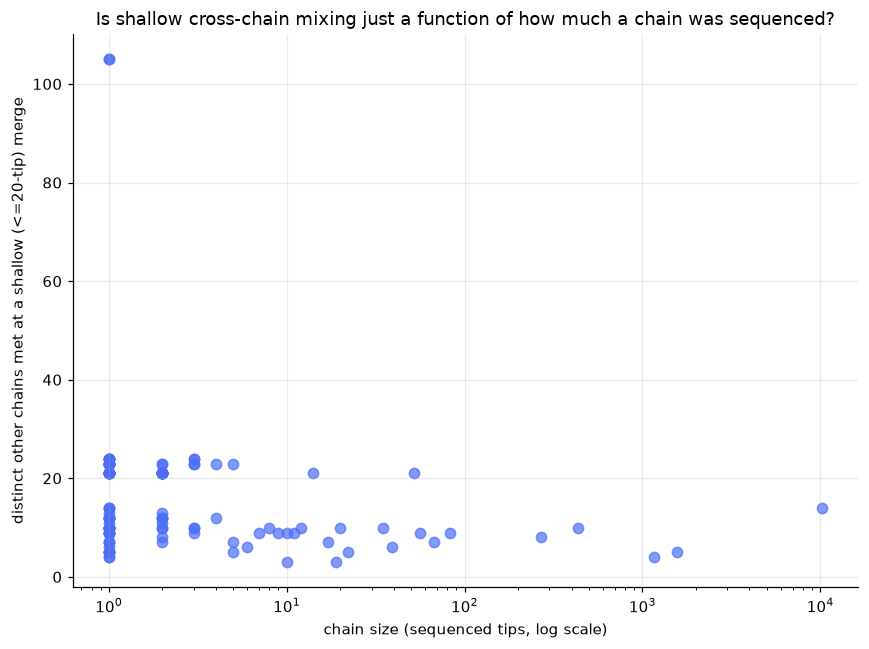

correlation (log sequenced tips vs. shallow other-chains): r=-0.208


In [28]:
SHALLOW_MAX_TIPS = 20
shallow_nodes = set(node_summary.loc[node_summary['smallest_side_tips'] <= SHALLOW_MAX_TIPS, 'node'])
shallow_merges = merges_df[merges_df['node'].isin(shallow_nodes)]
chain_summary_shallow = cc.summarize_chain_linkages(shallow_merges, tip_chain).rename(columns={
    'n_merge_nodes': 'n_shallow_merge_nodes', 'n_pair_rows': 'n_shallow_pair_rows',
    'n_other_chains': 'n_other_chains_shallow',
})
print(f"restricting to the {len(shallow_nodes)} shallow merge nodes (smallest side <= {SHALLOW_MAX_TIPS} tips): "
      f"{len(chain_summary_shallow)} of {len(chain_summary)} chains still appear, "
      f"n_other_chains_shallow now ranges {chain_summary_shallow.n_other_chains_shallow.min()}-"
      f"{chain_summary_shallow.n_other_chains_shallow.max()} instead of being fixed at "
      f"{chain_summary['n_other_chains'].iloc[0]}")

display(chain_summary_shallow.sort_values('n_other_chains_shallow', ascending=False)
        [['chain', 'n_sequenced_tips', 'n_shallow_merge_nodes', 'n_other_chains_shallow']].head(15))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(chain_summary_shallow['n_sequenced_tips'], chain_summary_shallow['n_other_chains_shallow'],
           color=COL['total'], alpha=.7, s=45)
ax.set_xscale('log')
ax.set_xlabel('chain size (sequenced tips, log scale)')
ax.set_ylabel(f'distinct other chains met at a shallow (<={SHALLOW_MAX_TIPS}-tip) merge')
ax.set_title('Is shallow cross-chain mixing just a function of how much a chain was sequenced?')
fig.tight_layout()
fig.savefig(f'{cc.RESULTS_DIR}/chain_linkage_vs_size.png', bbox_inches='tight')
plt.show()

log_tips = np.log(chain_summary_shallow['n_sequenced_tips'])
corr = np.corrcoef(log_tips, chain_summary_shallow['n_other_chains_shallow'])[0, 1]
print(f"correlation (log sequenced tips vs. shallow other-chains): r={corr:.3f}")

chain_summary.merge(chain_summary_shallow, on=['chain', 'n_sequenced_tips'], how='left') \
    .to_csv(f'{cc.RESULTS_DIR}/chain_linkage_summary.csv', index=False)


**The chain-by-chain leaderboard has two very different signatures hiding in it.** Chain 164 tops
`n_merge_nodes` (282) simply from scale -- it's 69% of every sequenced tip, so it's structurally present
almost everywhere. But several *singleton* chains also rank near the top (2192: 72 nodes, 2248: 58, 3596:
55, 1487: 46, 2266: 42) despite having exactly one sequenced tip each -- and for those, the pair-rows-per-node
ratio is low (chain 2192: 268 pairs over 72 nodes, ~3.7 newly-met chains per node). That pattern fits a lone
tip sitting on a long, thinly-branching path toward the root, picking up one incremental "first-time"
pairing at nearly every ancestor along the way -- a tree-topology artifact of *where* that tip sits, not a
sign of unusually broad relationships.

Restricting to shallow merges and re-ranking by `n_other_chains_shallow` surfaces a genuinely different,
more substantive pattern: chain 2281 (1 tip) reaches **105** distinct other chains through a *single* merge
node, and chain 3431 (1 tip) reaches the same 105 through just two. That's not gradual climbing -- it's one
(or two) specific points in the tree where on the order of a hundred separate, causally-unconnected chains'
samples all converge almost at once. That's very likely the same phenomenon the "expected" example above
sits inside, just a much bigger version of it -- the 30-tip cap used to keep that example readable only
showed 14 of what may be close to a hundred chains sharing that same neighborhood.

The weak negative correlation found above (r=-0.208, chain size vs. shallow other-chains) is consistent
with this: being heavily sequenced is *not* what drives shallow cross-chain exposure. If anything, the
chains most tightly enmeshed with others at a shallow, potentially-misleading level are themselves sparse
ones -- fitting many small, similarly-seeded introductions clustering together, rather than "big chains are
hubs because they're everywhere."


### Demographic and geographic context: cross-chain vs. within-chain pairs

Every tip carries two attributes that play no role at all in how the simulated pathogen genome evolves or
how TreeTime places a tip: age band (five ordered categories, Preschool through Senior) and county of
residence. If cross-chain merges really are spurious -- chance genetic resemblance between two
epidemiologically unconnected chains, not a real link -- pairs on either side of one should look
demographically and geographically like two *random* sequenced individuals. Pairs sampled *within* a real
transmission chain, by contrast, are a genuine epidemiological link by construction, so they should reflect
whatever contact structure actually drives transmission -- most visibly, geography.

Cross-chain pairs here are every merge where both sides' exact tip identities are known (`tips_a`/`tips_b`,
capped at small subtrees -- see the caveat on this earlier); within-chain pairs reuse the exact same sampled
pairs already computed for Section 5 (`pair_error_df`), just mapped from epi nodes to their genomic tip
names.


In [29]:
cross_pairs_df = cc.build_cross_chain_tip_pairs(merges_df, tip_chain)
print(f"cross-chain tip-pairs: {len(cross_pairs_df)}")

# Guarantee the premise: a genuinely cross-chain pair must have NO common
# ancestor anywhere in the transmission forest. (The raw tips_a x tips_b
# product does not satisfy this -- see build_cross_chain_tip_pairs.)
n_shared = sum(
    cc.lowest_common_ancestor(gen_to_epi[r.tip_a], gen_to_epi[r.tip_b], epi_parent) is not None
    for r in cross_pairs_df.itertuples(index=False)
)
print(f"sanity check -- pairs sharing a transmission-forest ancestor: {n_shared} (must be 0)")
assert n_shared == 0

cross_demo = cc.annotate_pair_demographics(cross_pairs_df, 'tip_a', 'tip_b', tip_demo)

within_df = pair_error_df[['epi_a', 'epi_b']].copy()
within_df['tip_a'] = within_df['epi_a'].map(epi_to_gen)
within_df['tip_b'] = within_df['epi_b'].map(epi_to_gen)
within_demo = cc.annotate_pair_demographics(within_df, 'tip_a', 'tip_b', tip_demo)

county_counts = pd.Series([v['county'] for v in tip_demo.values() if v['county']]).value_counts(normalize=True)
random_same_county = (county_counts ** 2).sum()

summary = pd.DataFrame([
    {'group': 'cross-chain merge', 'n_pairs': len(cross_demo),
     'mean_age_band_gap': cross_demo['age_band_gap'].mean(), 'same_county_rate': cross_demo['same_county'].mean()},
    {'group': 'within-chain (Section 5 sample)', 'n_pairs': len(within_demo),
     'mean_age_band_gap': within_demo['age_band_gap'].mean(), 'same_county_rate': within_demo['same_county'].mean()},
    {'group': 'random pair of sequenced tips (baseline)', 'n_pairs': len(tip_demo),
     'mean_age_band_gap': np.nan, 'same_county_rate': random_same_county},
])
display(summary.round(4))
summary.to_csv(f'{cc.RESULTS_DIR}/cross_vs_within_demographics.csv', index=False)


cross-chain tip-pairs: 664
sanity check -- pairs sharing a transmission-forest ancestor: 0 (must be 0)


,group,n_pairs,mean_age_band_gap,same_county_rate
0,cross-chain merge,664,1.0361,0.0482
1,within-chain (Section 5 sample),7714,1.0970,0.2416
2,random pair of sequenced tips (baseline),14793,NaN,0.0538


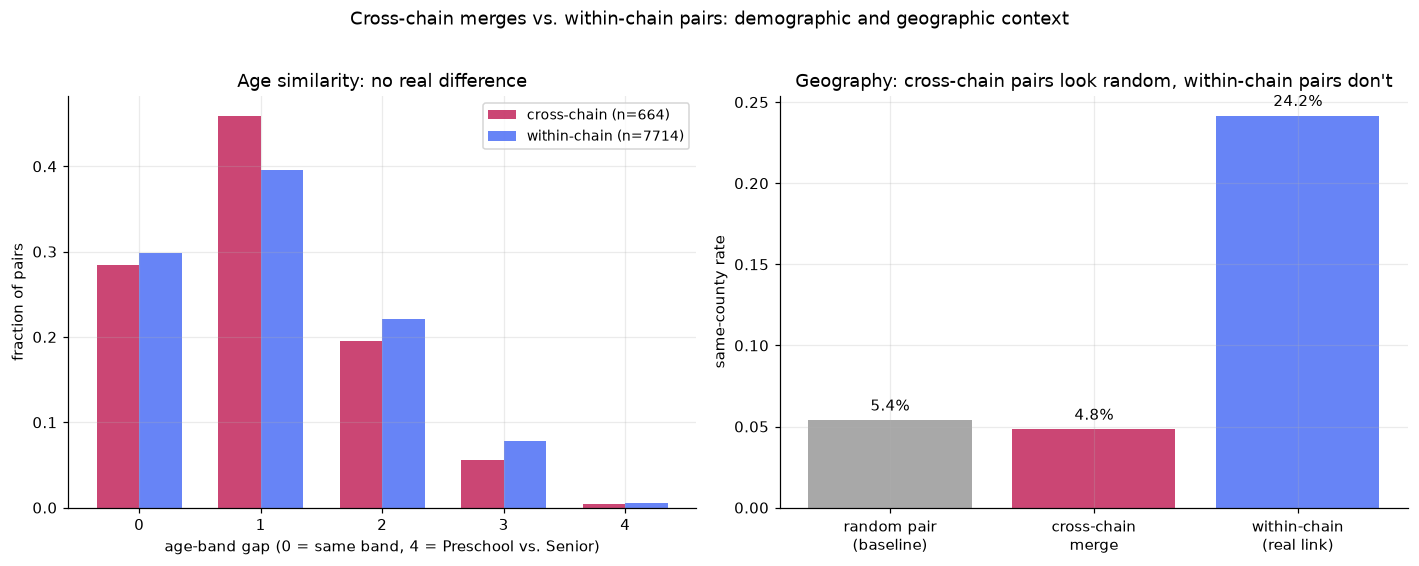

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
gap_labels = [0, 1, 2, 3, 4]
cross_frac = cross_demo['age_band_gap'].value_counts(normalize=True).reindex(gap_labels, fill_value=0)
within_frac = within_demo['age_band_gap'].value_counts(normalize=True).reindex(gap_labels, fill_value=0)
x = np.arange(len(gap_labels))
w = 0.35
ax.bar(x - w/2, cross_frac.values, w, label=f'cross-chain (n={len(cross_demo)})', color=COL['zero'], alpha=.85)
ax.bar(x + w/2, within_frac.values, w, label=f'within-chain (n={len(within_demo)})', color=COL['total'], alpha=.85)
ax.set_xticks(x); ax.set_xticklabels(gap_labels)
ax.set_xlabel('age-band gap (0 = same band, 4 = Preschool vs. Senior)')
ax.set_ylabel('fraction of pairs')
ax.set_title('Age similarity: no real difference')
ax.legend(fontsize=9)

ax = axes[1]
groups = ['random pair\n(baseline)', 'cross-chain\nmerge', 'within-chain\n(real link)']
rates = [random_same_county, cross_demo['same_county'].mean(), within_demo['same_county'].mean()]
colors = ['0.6', COL['zero'], COL['total']]
ax.bar(groups, rates, color=colors, alpha=.85)
for i, r in enumerate(rates):
    ax.text(i, r + .006, f'{r:.1%}', ha='center', fontsize=10)
ax.set_ylabel('same-county rate')
ax.set_title("Geography: cross-chain pairs look random, within-chain pairs don't")

fig.suptitle('Cross-chain merges vs. within-chain pairs: demographic and geographic context', y=1.02)
fig.tight_layout()
fig.savefig(f'{cc.RESULTS_DIR}/cross_vs_within_demographics.png', bbox_inches='tight')
plt.show()


**Age carries no signal here, but geography carries a lot.** Mean age-band gap is essentially identical
between the two groups (1.04 cross-chain vs. 1.10 within-chain, on a 0-4 scale) -- unsurprising, since
nothing about age enters into how the simulated genome mutates or how TreeTime places a tip, so both groups
just reflect the same background age-mixing pattern of who infects whom, real link or not.

Geography is a different story, and the result is about as clean as it gets. Two sequenced tips picked
completely at random share a county 5.4% of the time (the population's own concentration, driven mostly by
Fairfax, Spotsylvania, and Prince William). Cross-chain merge pairs sit at **4.8%** -- statistically
indistinguishable from picking two people at random out of the whole sequenced population. Within-chain
pairs, a real transmission link by construction, sit at **24.2%**, five times the random rate.

That's an independent confirmation, from data the phylogeny never saw, that these cross-chain merges carry
no epidemiological content whatsoever: the one signal a genuine transmission link reliably leaves -- two
people sharing a county -- is entirely absent from the pairs the tree groups together across chains. It is
not merely weaker than a real link; it is exactly what random pairing looks like.


### Error in the time between infections: cross-chain vs. within-chain

Section 5 measured, for pairs *within* a chain, how far the phylogeny's estimate of the time separating two
infections departs from the truth: genomic estimate (both tips' distance to their inferred MRCA) minus the
real quantity (both tips' distance to their actual shared infector). Asking the same question of
cross-chain pairs runs into something more fundamental than a bigger error bar: **these pairs have no
shared infector at all**, so the true separation isn't a larger number -- it doesn't exist. The tree is not
mis-estimating a real quantity, it is inventing one.

Two things can still be measured, and both are informative:

1. **What the tree claims.** The genomic separation it asserts is directly comparable between the two
   groups. If unrelated pairs get assigned separations in the same range as genuinely-related ones, then
   nobody reading the tree can use branch depth to tell a real link from a fabricated one.
2. **A provable lower bound on the truth.** Any common ancestry between two separately-seeded chains must
   predate *both* chains' introductions, so the true separation is at least
   `(tick_a - seed_a) + (tick_b - seed_b)` -- each tip walked back to its own chain's seed. The genomic
   estimate minus that bound (`min_error_days`) is a conservative, signed statement of how far the tree
   falls short of even the most generous reading of the truth.


In [31]:
chain_seed_tick = dict(zip(component_df['component_id'], component_df['min_tick']))
cross_err = cc.compute_cross_chain_duration_errors(
    cross_pairs_df, gen_num_date, tick_of_gen_leaf, tip_chain, chain_seed_tick
)
cross_err.to_csv(f'{cc.RESULTS_DIR}/cross_chain_duration_errors.csv', index=False)

per_chain_within = pair_error_df.groupby('component_id')['error_days'].mean()
per_node_cross = cross_err.groupby('node')['min_error_days'].mean()

dur_summary = pd.DataFrame([
    {'group': 'within-chain (real link)', 'n_pairs': len(pair_error_df),
     'genomic_median_days': pair_error_df['genomic_duration_days'].median(),
     'truth_median_days': pair_error_df['actual_duration_days'].median(),
     'truth_kind': 'exact',
     'error_median_days': pair_error_df['error_days'].median(),
     'clustered_mean_error_days': per_chain_within.mean(),
     'clustered_sem_days': per_chain_within.std(ddof=1) / np.sqrt(len(per_chain_within)),
     'n_clusters': len(per_chain_within)},
    {'group': 'cross-chain merge (no real link)', 'n_pairs': len(cross_err),
     'genomic_median_days': cross_err['genomic_duration_days'].median(),
     'truth_median_days': cross_err['min_true_duration_days'].median(),
     'truth_kind': 'lower bound only',
     'error_median_days': cross_err['min_error_days'].median(),
     'clustered_mean_error_days': per_node_cross.mean(),
     'clustered_sem_days': per_node_cross.std(ddof=1) / np.sqrt(len(per_node_cross)),
     'n_clusters': len(per_node_cross)},
])
display(dur_summary.round(1))

# How separable are the two groups by the tree's own claimed distance?
a = cross_err['genomic_duration_days'].values
b = np.sort(pair_error_df['genomic_duration_days'].values)
p_cross_closer = (len(b) - np.searchsorted(b, a, side='right')).sum() / (len(a) * len(b))
within_median = pair_error_df['genomic_duration_days'].median()
frac_below = (cross_err['genomic_duration_days'] < within_median).mean()

print(f"P(a random cross-chain pair looks CLOSER than a random within-chain pair) = {p_cross_closer:.3f} "
      "(0.5 would mean completely indistinguishable)")
print(f"fraction of cross-chain pairs assigned a separation shorter than the median genuinely-linked "
      f"pair ({within_median:.0f}d): {frac_below:.3f}")
print(f"fraction of cross-chain pairs provably too short (below the lower bound): "
      f"{(cross_err['min_error_days'] < 0).mean():.3f}")


,group,n_pairs,genomic_median_days,truth_median_days,truth_kind,error_median_days,clustered_mean_error_days,clustered_sem_days,n_clusters
0,within-chain (real link),7714,146.8,223.0,exact,-54.8,-64.3,5.4,59
1,cross-chain merge (no real link),664,220.6,155.0,lower bound only,76.1,-50.4,16.0,94


P(a random cross-chain pair looks CLOSER than a random within-chain pair) = 0.350 (0.5 would mean completely indistinguishable)
fraction of cross-chain pairs assigned a separation shorter than the median genuinely-linked pair (147d): 0.230
fraction of cross-chain pairs provably too short (below the lower bound): 0.244


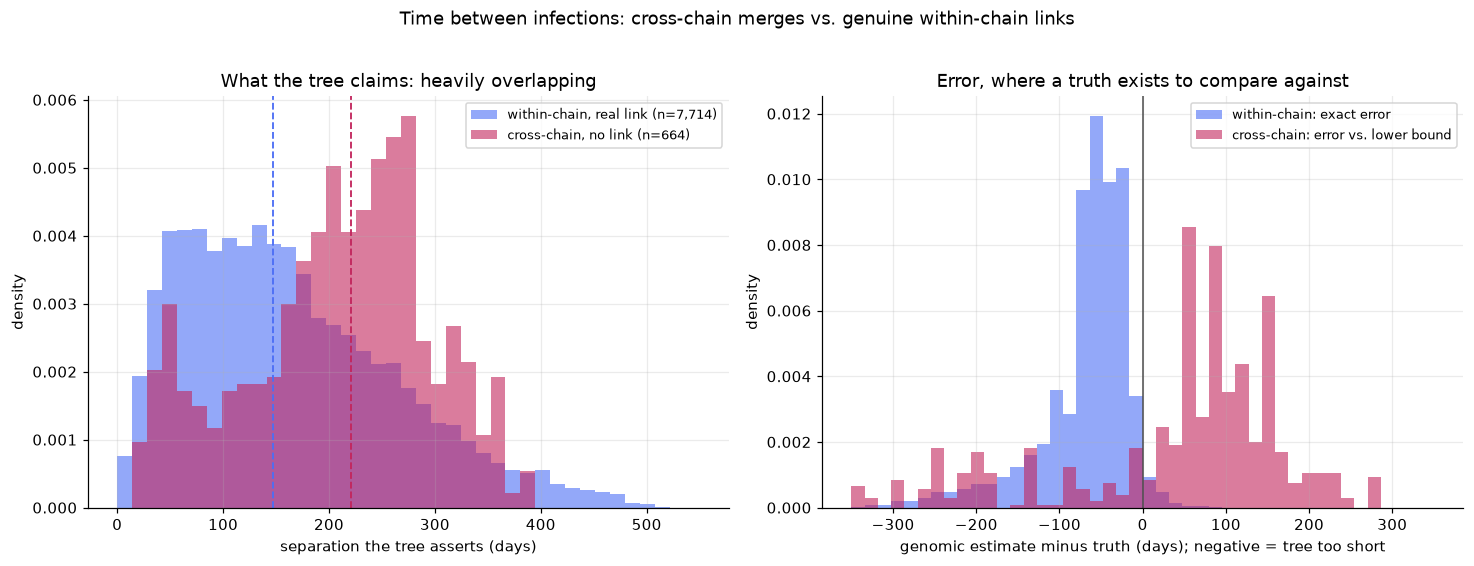

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))

ax = axes[0]
bins = np.linspace(0, 550, 40)
ax.hist(pair_error_df['genomic_duration_days'], bins=bins, density=True, alpha=.6,
        color=COL['total'], label=f'within-chain, real link (n={len(pair_error_df):,})')
ax.hist(cross_err['genomic_duration_days'], bins=bins, density=True, alpha=.6,
        color=COL['zero'], label=f'cross-chain, no link (n={len(cross_err):,})')
ax.axvline(pair_error_df['genomic_duration_days'].median(), color=COL['total'], ls='--', lw=1.2)
ax.axvline(cross_err['genomic_duration_days'].median(), color=COL['zero'], ls='--', lw=1.2)
ax.set_xlabel("separation the tree asserts (days)")
ax.set_ylabel('density')
ax.set_title('What the tree claims: heavily overlapping')
ax.legend(fontsize=8.5)

ax = axes[1]
bins2 = np.linspace(-350, 350, 45)
ax.hist(pair_error_df['error_days'], bins=bins2, density=True, alpha=.6, color=COL['total'],
        label='within-chain: exact error')
ax.hist(cross_err['min_error_days'], bins=bins2, density=True, alpha=.6, color=COL['zero'],
        label='cross-chain: error vs. lower bound')
ax.axvline(0, color='0.3', lw=1)
ax.set_xlabel('genomic estimate minus truth (days); negative = tree too short')
ax.set_ylabel('density')
ax.set_title('Error, where a truth exists to compare against')
ax.legend(fontsize=8.5)

fig.suptitle('Time between infections: cross-chain merges vs. genuine within-chain links', y=1.02)
fig.tight_layout()
fig.savefig(f'{cc.RESULTS_DIR}/cross_vs_within_duration_error.png', bbox_inches='tight')
plt.show()


**On average the tree gets the direction right; at the level of any individual pair it is not usable.**
Pairs with a genuine transmission link are assigned a median separation of 147 days; pairs with no
relationship whatsoever are assigned a median of 221 days. So unrelated things do sit further apart on
average, and P(a random cross-chain pair looks closer than a random within-chain pair) = 0.35, not 0.5 --
there is real discriminating signal in the aggregate.

But **23% of the cross-chain pairs -- pairs that share no transmission ancestor at all -- are assigned a
separation shorter than the median genuinely-linked pair.** Close to one in four fabricated links looks
*tighter* than a typical real one. Nothing about a single pair's MRCA depth licenses the conclusion that
the two infections are epidemiologically connected.

**The two failure modes are different in kind, and they compound each other.** For real links the error is
well defined and systematically negative: the tree compresses a true median 223 days down to 147, a
chain-clustered mean bias of **-64.3 +/- 5.4 days** (59 chains) -- the deep-branch compression established
in Section 5. For non-links there is no true value to be wrong about, but measured against the conservative
lower bound (ancestry must predate both chains' seeds), the typical merge *node* asserts an ancestor
**50.4 +/- 16.0 days more recent** than even that bound permits (94 nodes). Note the pooled median for the
same quantity is +76 days: as in Section 5, a handful of heavily-sampled merge points dominate the pooled
figure, which is why the node-clustered number is the one to read.

Those two biases push in the same unhelpful direction. Compression drags genuinely-linked pairs *down*
toward the fabricated ones, while fabricated pairs are handed plausibly recent ancestors -- squeezing the
gap between "really related" and "not related at all" from both sides at once.

One caveat on the lower bound: it is deliberately weak, and only 24% of cross-chain pairs violate it
outright. That is *not* evidence the other 76% are fine. The bound only asserts that common ancestry
predates both seeds; the actual truth for every one of these pairs is that no common ancestor exists in the
simulation at all, so any finite separation the tree reports is qualitatively wrong regardless of whether
it clears the bound.


**Caveats**

- This says nothing about the phylogeny being "wrong" in an absolute sense -- there's no independent truth
  for genomic placement here beyond the epi simulation's own transmission-chain boundaries. It says the
  genomic tree and the true transmission forest disagree about which infections are related, and
  characterizes exactly where and how.
- The 62 true-singleton chains' "is this the earliest sample" question is tautological by construction and
  is reported separately from the 180 meaningful multi-tip-chain outlier events for that reason.
- A handful of merge nodes are large polytomies (one node in this tree has 86 children); the node-level
  view (`summarize_merge_nodes`) and event-level view (`classify_merge_anchors`) both collapse the
  resulting pairwise combinatorics down to one row per real structural event, but a single hub node
  combining many chains at once is still counted once, not decomposed further.
- `extract_context_subtree`'s tip cap (30 by default) is only a display convenience for keeping an example
  figure readable -- it can and does cut off a larger real cluster mid-way, as the chain-by-chain view's
  105-other-chains findings show. Treat any single example figure as a slice of the local structure, not
  its full extent.
- `summarize_chain_linkages` deliberately double-counts by design (a chain meeting 40 others at one hub
  node is 40 linkages from that chain's own point of view) -- it answers "how exposed is this chain", not
  "how many independent events are there" (that's `summarize_merge_nodes`). The two are not comparable
  row-for-row.
- Age band and county come from the augur run's own input metadata (`metadata_with_index.tsv`), not
  `gen_G` itself -- county name specifically isn't on the graph or in that file directly (its own `county`
  column is empty); it's resolved from `county_fips` via a fips->name lookup built once from an unrelated
  population linelist (stable Census codes, so this is safe even though that linelist's own per-person
  records don't correspond to this run's tips).
- The cross-chain pair set (664 pairs) only covers merges where both sides kept an exact tip list
  (`tips_a`/`tips_b` non-None, i.e. <=8 tips -- 177 of 9,022 merge rows), so it is biased toward the
  *shallower* merges characterized above, not the full set. Note also that the raw `tips_a` x `tips_b`
  product is **not** a valid cross-chain pair set: a subtree can carry more than one chain, so 263 of the
  927 raw products were same-chain pairs (concentrated in the non-monophyletic big chains 164/240/562/136/
  187) that do share a real transmission ancestor. `build_cross_chain_tip_pairs` drops them, and the
  notebook asserts that none of the survivors has a common ancestor in the transmission forest.


## 9. Saved outputs

In [33]:
for f in sorted(os.listdir(cc.RESULTS_DIR)):
    print(f'  {f:38s} {os.path.getsize(os.path.join(cc.RESULTS_DIR, f)):>10,} bytes')


  capture_by_threshold_windowed.csv           2,083 bytes
  capture_by_threshold_windowed.png         104,253 bytes
  chain_activity_windows.png                147,984 bytes
  chain_linkage_events_ranked.png            40,031 bytes
  chain_linkage_summary.csv                   3,879 bytes
  chain_linkage_vs_size.png                  55,895 bytes
  component_stats.csv                       315,260 bytes
  cross_chain_duration_errors.csv            86,183 bytes
  cross_chain_merge_depth.png                41,795 bytes
  cross_chain_merge_scatter.png             118,188 bytes
  cross_chain_merges.csv                    481,954 bytes
  cross_chain_outlier_events.csv              8,349 bytes
  cross_vs_within_demographics.csv              254 bytes
  cross_vs_within_demographics.png           88,014 bytes
  cross_vs_within_duration_error.png         97,912 bytes
  daily_epi_context.png                     239,811 bytes
  daily_epi_stats.csv                        23,030 bytes
  duration_err

## 10. What this revision says

**The "near-complete in-window capture" premise doesn't hold.** Pooled across every chain, only ~0.25% of
infections that occurred during the sequencing window were ever sequenced -- about 1 in 400, not "all or
most." Three quarters of chains with onward in-window transmission have exactly zero sequenced cases.

**Windowing fixes the categorization.** Measured against full chain lifetime, a 4-26 week threshold barely
changed anything (Section 2's motivation for this revision). Measured against in-window persistence, the
same sweep now drops the number of qualifying chains by 92% (473 -> 36) -- it's discriminating real
structure. What it discriminates, though, is *whether a chain has even one sequenced case*, not *how
thoroughly* it was sequenced -- the pooled capture rate stays flat near 0.248% regardless of threshold, so
ascertainment behaves like a constant background rate rather than something driven by persistence.

**Genomic dating bias scales with how long the chain has been circulating.** Chain-clustered mean bias
grows from about -13 days for chains that persisted only 4-9 weeks in the window (2 chains) through -11 d
(9-14wk, 3 chains) and -43 d (14-19wk, 9 chains) to -59 d (19-26wk, 15 chains) and **-82 d for chains that
ran nearly the full 36-week window (30 chains)**. That gradient is the clearest evidence yet that this is
deep-branch compression rather than a fixed offset: error accumulates with the real separation between
infections, and in-window persistence is a proxy for exactly that separation.

### Caveats

- **The short-persistence bins are thin.** 4-9, 9-14, and 14-19 weeks together hold 18 pairs from 14
  chains total, with SEMs (13.0, 11.9, 9.8 days) comparable in size to the bias estimates themselves. The
  direction of the trend is consistent and mechanistically expected, but don't quote those three bin
  figures as precise -- they're closer to anecdotes than estimates. The two long-persistence bins are on
  firmer footing (SEM 6.4 and 8.1 days across 15 and 30 chains).
- **Pair sampling is capped at 500/chain**, so a plain per-pair average would let a handful of giant,
  heavily-resampled chains drown out chains that only contributed a few pairs. That's why every bin here
  is reported as `chain_mean_bias_days`/`chain_bias_sem_days` (mean and SEM of per-chain averages, treating
  each chain as one independent unit) rather than a per-pair mean -- and it matters: the naive per-pair
  bias for the top bin understates the true chain-clustered bias by 14 days (-68 d vs. -82 d).
- **`process_seed_nodes` has a labeling bug** (documented in `chain_capture_data.build_epi_indices`): a
  seed's self-loop is keyed on the original `pid`, not the `pid_updated` label used everywhere else, so
  ~3.8k of 15.4M nodes -- exactly the real chain roots -- are missing from the tick index under their
  proper name. Patched here with a lower-bound proxy (earliest known child tick).

### Reasonable next steps

- **Bootstrap at the chain level** (resample chains with replacement, not pairs) to put a real confidence
  band on each persistence bin, especially the thin short-duration ones.
- If more replicate simulations of this scenario exist, pool them to get more short/medium-persistence
  chains with >=2 sequenced infections -- right now that regime is data-starved by nothing but chance.
- Push to the **branch level** (single parent-child transmission pairs) to see whether the persistence
  gradient found here is really about elapsed time, or specifically about tree *depth* (number of
  intervening unsampled generations), which persistence conflates.
